<a href="https://colab.research.google.com/github/RizkiHadiono/244107020198-Pembelajaran-Mesin/blob/main/BisindoVision_Clustering_Kelompok1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏆 BisindoVision: Klasterisasi Bahasa Isyarat Indonesia (BISINDO)
## Komparasi K-Means vs DBSCAN dengan Euclidean, Manhattan, dan Cosine Similarity

**Proyek PBL (Product-Based Learning) - Mata Kuliah Pembelajaran Mesin**  
**Dataset:** Citra Isyarat Tangan Bisindo (A-Z, 26 Kelas)  
**Total Pipeline:** Ekstraksi Fitur → K-Means (3 metrik) → DBSCAN (3 metrik) → Perbandingan 6 Model

---

### 📌 Daftar Isi Notebook
1. **Tahap 0** - Setup & Ekstraksi Fitur MediaPipe (Gambar → CSV 63 Dimensi)
2. **Tahap 1** - K-Means Euclidean Distance ($L_2$)
3. **Tahap 2** - K-Means Manhattan Distance ($L_1$)
4. **Tahap 3** - K-Means Cosine Similarity (Spherical)
5. **Tahap 4** - Perbandingan K-Means (3 Metrik Jarak)
6. **Tahap 5** - DBSCAN Euclidean Distance ($L_2$)
7. **Tahap 6** - DBSCAN Manhattan Distance ($L_1$)
8. **Tahap 7** - DBSCAN Cosine Distance (Spherical)
9. **Tahap 8** - Perbandingan DBSCAN (3 Metrik Jarak)
10. **Tahap 9** - Komparasi Akhir 6 Model & Kesimpulan

---
# 📷 Tahap 0: Setup Google Colab & Ekstraksi Fitur MediaPipe

## 📌 Ringkasan
Algoritma klasterisasi (K-Means & DBSCAN) **tidak bisa** memproses susunan piksel gambar secara mentah. Kita butuh representasi data numerik berupa **pose jari**.

Notebook ini bertugas:
1. Mount Google Drive & mengunduh model pendeteksi tangan dari Google MediaPipe.
2. Membaca seluruh gambar dari kelas A-Z.
3. Mengekstrak 21 titik sendi (landmark) tangan per gambar. Tiap titik memiliki 3 sumbu ($x, y, z$), sehingga totalnya ada $21 \times 3 = 63$ fitur.
4. Menyimpan data tersebut menjadi file **`bisindo_landmarks.csv`**.

In [1]:
# =======================================================================
# 0.1 MOUNT GOOGLE DRIVE & INSTALL DEPENDENCIES
# =======================================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install mediapipe openpyxl -q

print("[INFO] Google Drive terhubung dan dependensi terinstal.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.8 MB/s eta 0:00:00
[INFO] Google Drive terhubung dan dependensi terinstal.


In [2]:
# =======================================================================
# 0.2 KONFIGURASI PATH (SESUAIKAN DENGAN GOOGLE DRIVE ANDA)
# =======================================================================
import os

# ⚠️ SESUAIKAN PATH INI DENGAN LOKASI FOLDER DATASET DI GOOGLE DRIVE ANDA
TRAIN_DIR = "/content/drive/MyDrive/Dataset_PBL"  # Folder berisi subfolder A, B, C, ... Z

# Folder output (akan dibuat otomatis di Colab)
BASE_OUTPUT = "/content/output"
OUTPUT_KMEANS = os.path.join(BASE_OUTPUT, "outputKmeans")
OUTPUT_DBSCAN = os.path.join(BASE_OUTPUT, "outputDBScan")
OUTPUT_COMPARISON = os.path.join(BASE_OUTPUT, "outputComparison")
DATASET_DIR = os.path.join(BASE_OUTPUT, "dataset")

for d in [OUTPUT_KMEANS, OUTPUT_DBSCAN, OUTPUT_COMPARISON, DATASET_DIR]:
    os.makedirs(d, exist_ok=True)

DATASET_CSV = os.path.join(DATASET_DIR, "bisindo_landmarks.csv")

print(f"[CONFIG] Train Dir     : {TRAIN_DIR}")
print(f"[CONFIG] Dataset CSV   : {DATASET_CSV}")
print(f"[CONFIG] Output KMeans : {OUTPUT_KMEANS}")
print(f"[CONFIG] Output DBSCAN : {OUTPUT_DBSCAN}")

[CONFIG] Train Dir     : /content/drive/MyDrive/Dataset_PBL
[CONFIG] Dataset CSV   : /content/output/dataset/bisindo_landmarks.csv
[CONFIG] Output KMeans : /content/output/outputKmeans
[CONFIG] Output DBSCAN : /content/output/outputDBScan


In [3]:
# =======================================================================
# 0.3 DOWNLOAD MODEL MEDIAPIPE & EKSTRAKSI FITUR
# =======================================================================
import urllib.request
import cv2
import pandas as pd
import time
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = '/content/hand_landmarker.task'
model_url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'

if not os.path.exists(model_path):
    print("[INFO] Mengunduh model Google MediaPipe Hand Landmarker...")
    urllib.request.urlretrieve(model_url, model_path)
    print("[SUCCESS] Model berhasil diunduh!")
else:
    print("[INFO] Model sudah tersedia lokal.")

# Inisialisasi Model MediaPipe
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5
)
detector = vision.HandLandmarker.create_from_options(options)

data = []
classes = sorted(os.listdir(TRAIN_DIR))

total_images = sum([len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes if os.path.isdir(os.path.join(TRAIN_DIR, c))])
print(f"[START] Memproses total {total_images} citra...")

start_time = time.time()
processed_count = 0
detected_count = 0

for label in classes:
    folder_path = os.path.join(TRAIN_DIR, label)
    if not os.path.isdir(folder_path):
        continue

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = os.path.join(folder_path, filename)
        mp_image = mp.Image.create_from_file(img_path)

        processed_count += 1
        detection_result = detector.detect(mp_image)

        if detection_result.hand_landmarks:
            hand_landmarks = detection_result.hand_landmarks[0]
            row = {'label': label, 'filename': filename}

            for i, lm in enumerate(hand_landmarks):
                row[f'x{i}'] = lm.x
                row[f'y{i}'] = lm.y
                row[f'z{i}'] = lm.z

            data.append(row)
            detected_count += 1

        if processed_count % 1500 == 0:
            print(f" -> Diproses: {processed_count}/{total_images} gambar. Tangan ditemukan: {detected_count}")

elapsed = time.time() - start_time
print(f"\n[DONE] Selesai memproses dalam {elapsed:.2f} detik.")
print(f"[INFO] Tangan berhasil terdeteksi pada {detected_count} gambar.")

df = pd.DataFrame(data)
df.to_csv(DATASET_CSV, index=False)
print(f"[SUCCESS] Dataset berhasil diekspor ke: '{DATASET_CSV}'")
print(f"[INFO] Dimensi dataset final: {df.shape[0]} baris x {df.shape[1]} kolom.")
df.head()

[INFO] Mengunduh model Google MediaPipe Hand Landmarker...
[SUCCESS] Model berhasil diunduh!
[START] Memproses total 9169 citra...
 -> Diproses: 1500/9169 gambar. Tangan ditemukan: 1084
 -> Diproses: 3000/9169 gambar. Tangan ditemukan: 2226
 -> Diproses: 4500/9169 gambar. Tangan ditemukan: 3484
 -> Diproses: 6000/9169 gambar. Tangan ditemukan: 4806
 -> Diproses: 7500/9169 gambar. Tangan ditemukan: 6013
 -> Diproses: 9000/9169 gambar. Tangan ditemukan: 7110

[DONE] Selesai memproses dalam 585.73 detik.
[INFO] Tangan berhasil terdeteksi pada 7233 gambar.
[SUCCESS] Dataset berhasil diekspor ke: '/content/output/dataset/bisindo_landmarks.csv'
[INFO] Dimensi dataset final: 7233 baris x 65 kolom.


,label,filename,x0,y0,z0,x1,y1,z1,x2,y2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,A,IMG_20191210_180224.jpg,0.882249,0.848592,1.545304e-07,0.806316,0.830931,-0.065734,0.711917,0.785565,...,-0.072326,0.902702,0.583053,-0.102733,0.909482,0.632115,-0.099914,0.900300,0.677490,-0.092341
1,A,augmented_image_12.jpg,0.167700,0.736591,7.796234e-07,0.258136,0.759461,-0.129155,0.345109,0.732452,...,-0.038224,0.205856,0.425851,-0.098040,0.199824,0.482743,-0.103279,0.207088,0.524657,-0.093376
2,A,augmented_image_10.jpg,0.845277,0.759842,2.163168e-07,0.737246,0.760714,-0.083510,0.647699,0.734810,...,-0.035231,0.787678,0.409392,-0.062130,0.794909,0.475792,-0.049486,0.796750,0.523544,-0.031638
3,A,augmented_image_11.jpg,0.197128,0.851152,5.003820e-07,0.300964,0.831663,-0.100257,0.377907,0.775839,...,-0.012955,0.208461,0.518237,-0.041867,0.213614,0.576532,-0.032308,0.223139,0.620759,-0.019568
4,A,IMG_20191210_180205.jpg,0.882411,0.743552,-2.818054e-07,0.796780,0.734575,-0.050748,0.687631,0.692990,...,-0.108429,0.929048,0.569228,-0.136755,0.911669,0.624063,-0.125908,0.892999,0.644864,-0.110422


---
# 📊 Tahap 1: K-Means Clustering - Euclidean Distance ($L_2$ Norm)

## 📐 Formulasi Matematis Euclidean Distance & Fungsi Objektif

### 1.1. Euclidean Distance ($L_2$ Norm)
Jarak garis lurus antara dua titik data $x, y \in \mathbb{R}^n$:
$$d_{\text{Euclidean}}(x, y) = \|x - y\|_2 = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

### 1.2. Fungsi Objektif (Within-Cluster Sum of Squares / SSE)
$$J_{\text{Euclidean}} = \sum_{k=1}^{K} \sum_{x \in S_k} \|x - \mu_k\|_2^2$$

> **Pembaruan Titik Pusat (Centroid Update Rule):**  
> $$\mu_k^* = \frac{1}{|S_k|} \sum_{x \in S_k} x$$

In [4]:
# =======================================================================
# 1.1 SETUP & IMPORT PUSTAKA
# =======================================================================
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Pustaka berhasil dimuat.")

[INFO] Pustaka berhasil dimuat.


In [5]:
# =======================================================================
# 1.2 PEMUATAN DATASET & PRA-PEMROSESAN
# =======================================================================
def load_and_preprocess_data():
    print(f"[DATA] Membaca dataset dari: '{DATASET_CSV}'")
    df_raw = pd.read_csv(DATASET_CSV)
    print(f"[DATA] Dimensi awal dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

    cols_to_drop = ['label', 'filename']
    df_features = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features.values)

    return df_raw, df_features, X_scaled

df_raw, df_features, X_scaled = load_and_preprocess_data()
print(f"[DATA] Fitur siap dimodelkan ({X_scaled.shape[1]} dimensi): {list(df_features.columns)[:5]} ...")
df_features.head()

[DATA] Membaca dataset dari: '/content/output/dataset/bisindo_landmarks.csv'
[DATA] Dimensi awal dataset: 7233 baris x 65 kolom
[DATA] Fitur siap dimodelkan (63 dimensi): ['x0', 'y0', 'z0', 'x1', 'y1'] ...


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,0.882249,0.848592,1.545304e-07,0.806316,0.830931,-0.065734,0.711917,0.785565,-0.111018,0.617954,...,-0.072326,0.902702,0.583053,-0.102733,0.909482,0.632115,-0.099914,0.900300,0.677490,-0.092341
1,0.167700,0.736591,7.796234e-07,0.258136,0.759461,-0.129155,0.345109,0.732452,-0.195329,0.424371,...,-0.038224,0.205856,0.425851,-0.098040,0.199824,0.482743,-0.103279,0.207088,0.524657,-0.093376
2,0.845277,0.759842,2.163168e-07,0.737246,0.760714,-0.083510,0.647699,0.734810,-0.135582,0.559739,...,-0.035231,0.787678,0.409392,-0.062130,0.794909,0.475792,-0.049486,0.796750,0.523544,-0.031638
3,0.197128,0.851152,5.003820e-07,0.300964,0.831663,-0.100257,0.377907,0.775839,-0.138380,0.462070,...,-0.012955,0.208461,0.518237,-0.041867,0.213614,0.576532,-0.032308,0.223139,0.620759,-0.019568
4,0.882411,0.743552,-2.818054e-07,0.796780,0.734575,-0.050748,0.687631,0.692990,-0.092706,0.603411,...,-0.108429,0.929048,0.569228,-0.136755,0.911669,0.624063,-0.125908,0.892999,0.644864,-0.110422


[INFO] Menghitung Elbow Method (ini bisa memakan waktu)...
[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 10
[INFO] Override K dengan 26 (sesuai jumlah alfabet Bisindo A-Z) untuk analisis.
[SIMPAN] Grafik Elbow disimpan ke: '/content/output/outputKmeans/elbow_euclidean.png'


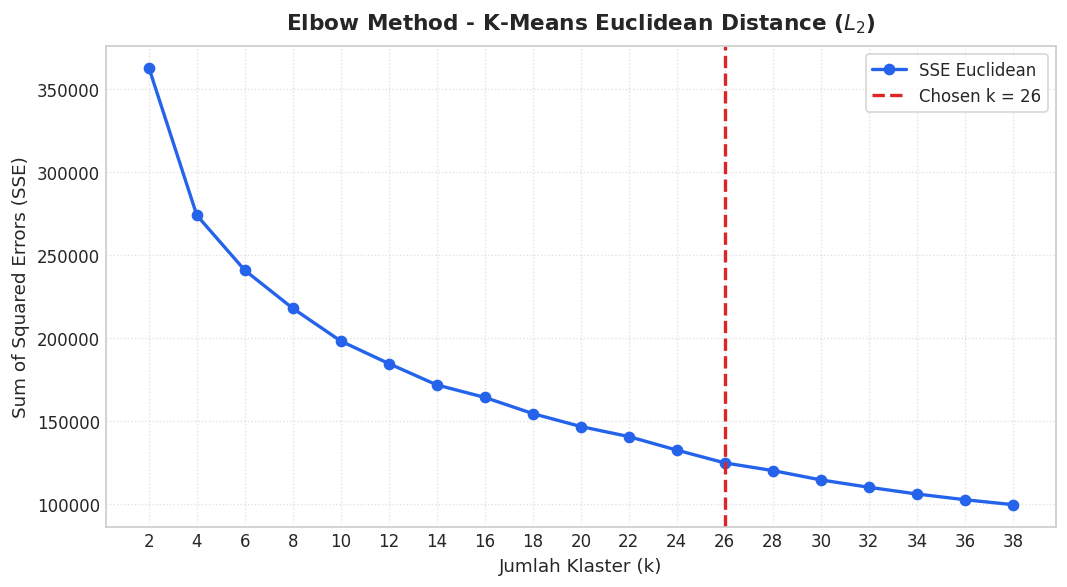

In [6]:
# =======================================================================
# 1.3 METODE ELBOW EUCLIDEAN & PENENTUAN K OPTIMAL
# =======================================================================
from sklearn.cluster import KMeans

k_range = list(range(2, 40, 2))
sse_euclidean = []

print("[INFO] Menghitung Elbow Method (ini bisa memakan waktu)...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse_euclidean.append(km.inertia_)

def find_elbow_point(k_vals, sses):
    p1 = np.array([k_vals[0], sses[0]])
    p2 = np.array([k_vals[-1], sses[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit) for k, s in zip(k_vals, sses)]
    return k_vals[np.argmax(dists)]

optimal_k = find_elbow_point(k_range, sse_euclidean)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

optimal_k = 26
print(f"[INFO] Override K dengan {optimal_k} (sesuai jumlah alfabet Bisindo A-Z) untuk analisis.")

plt.figure(figsize=(9, 5))
plt.plot(k_range, sse_euclidean, marker='o', markersize=6, linewidth=2, color='#2563EB', label='SSE Euclidean')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Chosen k = {optimal_k}')

plt.title('Elbow Method - K-Means Euclidean Distance ($L_2$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_KMEANS, "elbow_euclidean.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [7]:
# =======================================================================
# 1.4 KELAS K-MEANS EUCLIDEAN (CUSTOM IMPLEMENTATION)
# =======================================================================
class KMeansEuclidean:
    def __init__(self, n_clusters=26, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='euclidean')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.mean(cluster_pts, axis=0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists ** 2))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.")

[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.


In [8]:
# =======================================================================
# 1.5 EKSEKUSI CLUSTERING, METRIK EVALUASI, & EKSPOR EXCEL
# =======================================================================
print(f"[INFO] Menjalankan Custom KMeans Euclidean dengan k={optimal_k}...")
model_euclidean = KMeansEuclidean(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_euclidean.fit(X_scaled)

eval_size = min(5000, len(X_scaled))
rng_eval = np.random.RandomState(RANDOM_STATE)
eval_indices = rng_eval.choice(len(X_scaled), eval_size, replace=False)

X_eval = X_scaled[eval_indices]
labels_eval = model_euclidean.labels_[eval_indices]

print("[INFO] Menghitung metrik evaluasi...")
sil_score = float(silhouette_score(X_eval, labels_eval, metric='euclidean'))
db_score = float(davies_bouldin_score(X_eval, labels_eval))
ch_score = float(calinski_harabasz_score(X_eval, labels_eval))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean Distance (L2)',
    'Chosen k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_euclidean.execution_time_, 5),
    'Iterations (↓)': model_euclidean.n_iter_,
    'Objective Value (SSE) (↓)': round(model_euclidean.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS EUCLIDEAN")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

excel_path = os.path.join(OUTPUT_KMEANS, "evaluasi_kmeans_euclidean.xlsx")

df_clustered_euc = df_raw.copy()
df_clustered_euc['Cluster_Euclidean'] = model_euclidean.labels_

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered_euc.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")

[INFO] Menjalankan Custom KMeans Euclidean dengan k=26...
[INFO] Menghitung metrik evaluasi...

TABEL EVALUASI K-MEANS EUCLIDEAN
        Distance Metric  Chosen k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SSE) (↓)
Euclidean Distance (L2)        26                 0.221                     1.426                       477.33                  0.6152              36                  133048.52
[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '/content/output/outputKmeans/evaluasi_kmeans_euclidean.xlsx'


[INFO] Membangun visualisasi PCA 2D...
[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/output/outputKmeans/cluster_euclidean.png'


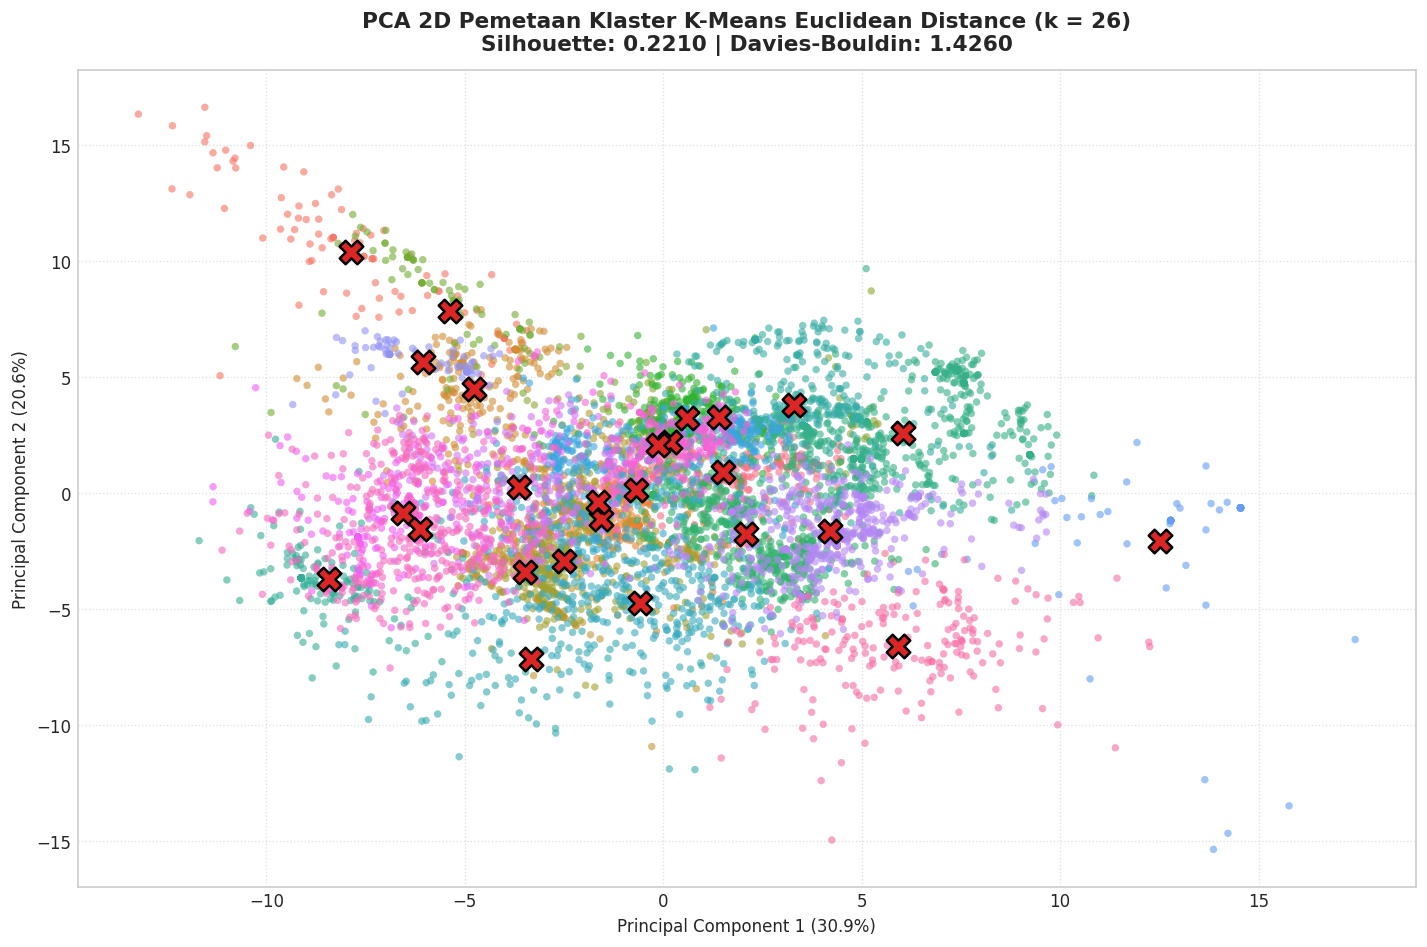

In [9]:
# =======================================================================
# 1.6 VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
print("[INFO] Membangun visualisasi PCA 2D...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_euclidean.centroids)

plt.figure(figsize=(12, 8))
palette = sns.color_palette("husl", optimal_k)

for k in range(optimal_k):
    mask = (model_euclidean.labels_ == k)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k],
                label=f'Klaster {k}' if optimal_k <= 10 else None, alpha=0.6, s=20, edgecolors='none')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='#DC2626',
            edgecolor='black', linewidth=1.5, label='Centroids' if optimal_k <= 10 else None, zorder=10)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Euclidean Distance (k = {optimal_k})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
if optimal_k <= 10:
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_KMEANS, "cluster_euclidean.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

---
# 📊 Tahap 2: K-Means Clustering - Manhattan Distance ($L_1$ Norm)

## 📐 Formulasi Matematis Manhattan Distance & Fungsi Objektif

### 2.1. Manhattan Distance ($L_1$ Norm)
$$d_{\text{Manhattan}}(x, y) = \|x - y\|_1 = \sum_{i=1}^{n} |x_i - y_i|$$

### 2.2. Fungsi Objektif (Sum of Absolute Errors / SAE)
$$J_{\text{Manhattan}} = \sum_{k=1}^{K} \sum_{x \in S_k} \sum_{j=1}^{n} |x_j - \mu_{k, j}|$$

> **Pembaruan Titik Pusat (K-Medians Principle):**  
> $$\mu_{k, j}^* = \text{median}(\{x_j : x \in S_k\})$$

In [10]:
# =======================================================================
# 2.1 KELAS K-MEANS MANHATTAN (K-MEDIANS PRINCIPLE)
# =======================================================================
class KMeansManhattan:
    def __init__(self, n_clusters=26, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='manhattan')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.median(cluster_pts, axis=0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansManhattan berhasil diinisialisasi.")

[INFO] Kelas KMeansManhattan berhasil diinisialisasi.


[INFO] Menghitung Elbow Method (Manhattan)...
[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 12
[INFO] Override K dengan 26 (jumlah kelas A-Z).
[SIMPAN] Grafik Elbow disimpan ke: '/content/output/outputKmeans/elbow_manhattan.png'


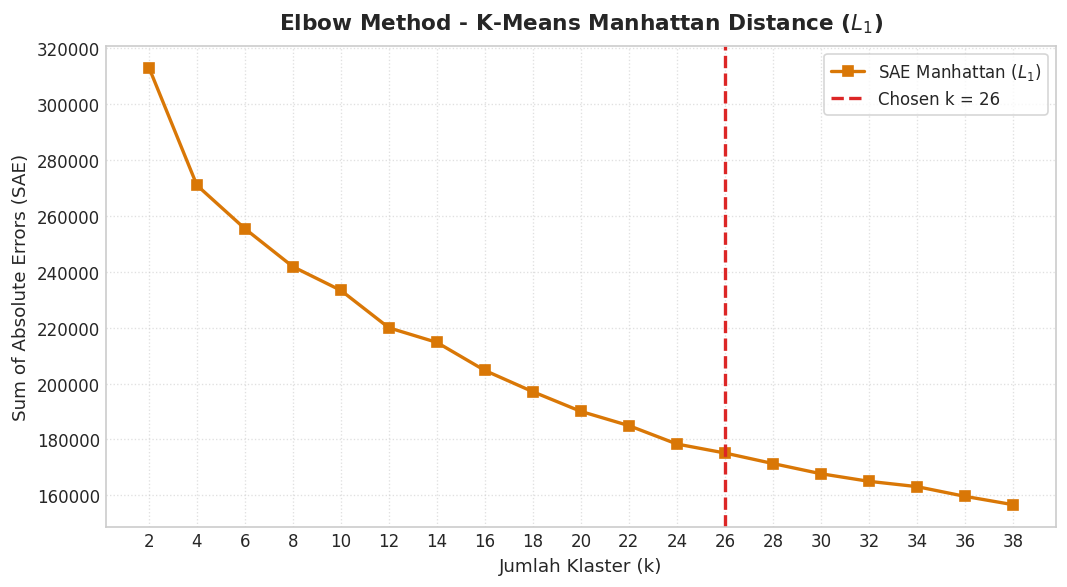

In [11]:
# =======================================================================
# 2.2 EKSEKUSI ELBOW METHOD MANHATTAN
# =======================================================================
k_range = list(range(2, 40, 2))
sae_manhattan = []

print("[INFO] Menghitung Elbow Method (Manhattan)...")
for k in k_range:
    km = KMeansManhattan(n_clusters=k, max_iter=200, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sae_manhattan.append(km.inertia_)

optimal_k = find_elbow_point(k_range, sae_manhattan)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

optimal_k = 26
print(f"[INFO] Override K dengan {optimal_k} (jumlah kelas A-Z).")

plt.figure(figsize=(9, 5))
plt.plot(k_range, sae_manhattan, marker='s', markersize=6, linewidth=2, color='#D97706', label='SAE Manhattan ($L_1$)')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Chosen k = {optimal_k}')

plt.title('Elbow Method - K-Means Manhattan Distance ($L_1$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Sum of Absolute Errors (SAE)', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_KMEANS, "elbow_manhattan.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [12]:
# =======================================================================
# 2.3 EKSEKUSI CLUSTERING, METRIK EVALUASI, & EKSPOR EXCEL
# =======================================================================
print(f"[INFO] Menjalankan Custom KMeans Manhattan dengan k={optimal_k}...")
model_manhattan = KMeansManhattan(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_manhattan.fit(X_scaled)

eval_size = min(5000, len(X_scaled))
rng_eval = np.random.RandomState(RANDOM_STATE)
eval_indices = rng_eval.choice(len(X_scaled), eval_size, replace=False)
X_eval = X_scaled[eval_indices]
labels_eval = model_manhattan.labels_[eval_indices]

print("[INFO] Menghitung metrik evaluasi...")
sil_score = float(silhouette_score(X_eval, labels_eval, metric='manhattan'))
db_score = float(davies_bouldin_score(X_eval, labels_eval))
ch_score = float(calinski_harabasz_score(X_eval, labels_eval))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Manhattan Distance (L1)',
    'Chosen k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_manhattan.execution_time_, 5),
    'Iterations (↓)': model_manhattan.n_iter_,
    'Objective Value (SAE) (↓)': round(model_manhattan.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS MANHATTAN")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

excel_path = os.path.join(OUTPUT_KMEANS, "evaluasi_kmeans_manhattan.xlsx")
df_clustered_man = df_raw.copy()
df_clustered_man['Cluster_Manhattan'] = model_manhattan.labels_

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered_man.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")

[INFO] Menjalankan Custom KMeans Manhattan dengan k=26...
[INFO] Menghitung metrik evaluasi...

TABEL EVALUASI K-MEANS MANHATTAN
        Distance Metric  Chosen k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SAE) (↓)
Manhattan Distance (L1)        26                0.2301                    1.4012                        494.7                 1.03678              32                  175164.57
[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '/content/output/outputKmeans/evaluasi_kmeans_manhattan.xlsx'


[INFO] Membangun visualisasi PCA 2D...
[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/output/outputKmeans/cluster_manhattan.png'


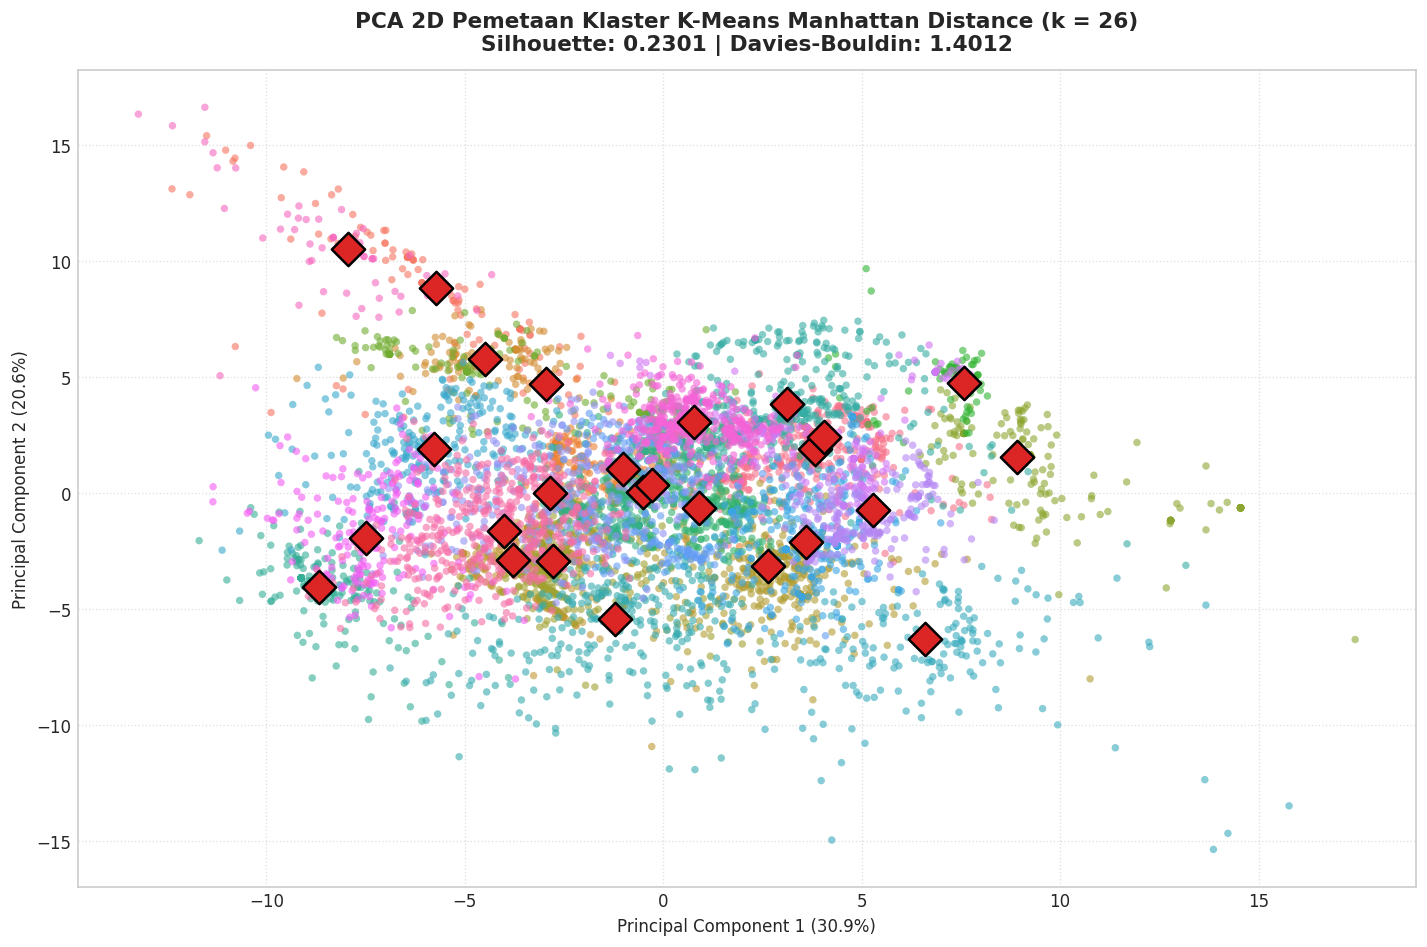

In [13]:
# =======================================================================
# 2.4 VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
print("[INFO] Membangun visualisasi PCA 2D...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_manhattan.centroids)

plt.figure(figsize=(12, 8))
palette = sns.color_palette("husl", optimal_k)

for k in range(optimal_k):
    mask = (model_manhattan.labels_ == k)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k],
                label=f'Klaster {k}' if optimal_k <= 10 else None, alpha=0.6, s=20, edgecolors='none')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='D', s=200, c='#DC2626',
            edgecolor='black', linewidth=1.5, label='Centroids' if optimal_k <= 10 else None, zorder=10)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Manhattan Distance (k = {optimal_k})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
if optimal_k <= 10:
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_KMEANS, "cluster_manhattan.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

---
# 📊 Tahap 3: K-Means Clustering - Cosine Similarity (Spherical K-Means)

## 📐 Formulasi Matematis Cosine Distance & Fungsi Objektif

### 3.1. Cosine Distance
$$d_{\text{Cosine}}(x, y) = 1 - \cos(x, y) = 1 - \frac{x \cdot y}{\|x\|_2 \|y\|_2}$$

### 3.2. Fungsi Objektif (Cosine Inertia)
$$J_{\text{Cosine}} = \sum_{k=1}^{K} \sum_{x \in S_k} d_{\text{Cosine}}(x, \mu_k)$$

> **Pembaruan Titik Pusat (Spherical K-Means):**  
> $$\mu_k^* = \frac{\sum_{x \in S_k} x}{\left\|\sum_{x \in S_k} x\right\|_2}$$

In [14]:
# =======================================================================
# 3.1 PEMUATAN DATASET & PRA-PEMROSESAN (L2 NORMALIZATION)
# =======================================================================
from sklearn.preprocessing import Normalizer

def load_and_preprocess_cosine():
    df_raw = pd.read_csv(DATASET_CSV)
    cols_to_drop = ['label', 'filename']
    df_features = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])

    scaler = StandardScaler()
    X_std = scaler.fit_transform(df_features.values)

    normalizer = Normalizer(norm='l2')
    X_norm = normalizer.fit_transform(X_std)

    return df_raw, df_features, X_norm

df_raw, df_features, X_norm = load_and_preprocess_cosine()
print(f"[DATA] Fitur siap dimodelkan ({X_norm.shape[1]} dimensi)")

[DATA] Fitur siap dimodelkan (63 dimensi)


In [15]:
# =======================================================================
# 3.2 KELAS K-MEANS COSINE (SPHERICAL K-MEANS)
# =======================================================================
class KMeansCosine:
    def __init__(self, n_clusters=26, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='cosine')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])

        centroids = np.array(centroids)
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        return centroids / norms

    def fit(self, X):
        start_time = time.perf_counter()

        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        X_calc = X / norms

        self.centroids = self._init_centroids(X_calc)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X_calc, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X_calc[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X_calc[rng.randint(len(X_calc))]
                else:
                    mean_vec = np.mean(cluster_pts, axis=0)
                    norm = np.linalg.norm(mean_vec)
                    new_centroids[k] = mean_vec / (norm if norm > 0 else 1.0)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        final_dists = self._compute_distance(X_calc, self.centroids)
        assigned_dists = final_dists[np.arange(len(X_calc)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansCosine berhasil diinisialisasi.")

[INFO] Kelas KMeansCosine berhasil diinisialisasi.


[INFO] Menghitung Elbow Method (Cosine)...
[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 12
[INFO] Override K dengan 26 (jumlah kelas A-Z).
[SIMPAN] Grafik Elbow disimpan ke: '/content/output/outputKmeans/elbow_cosine.png'


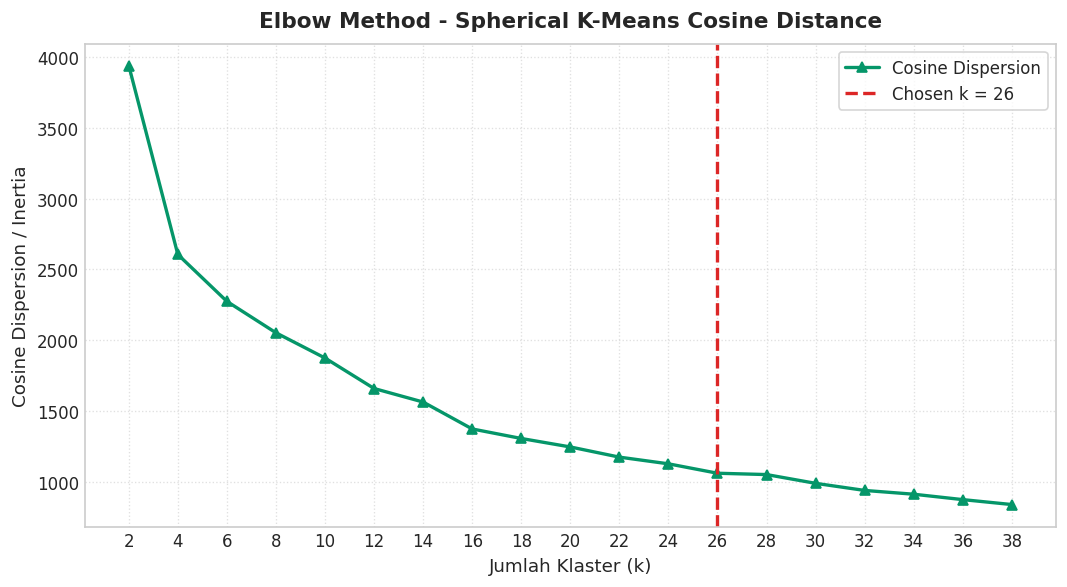

In [16]:
# =======================================================================
# 3.3 EKSEKUSI ELBOW METHOD COSINE
# =======================================================================
k_range = list(range(2, 40, 2))
inertia_cosine = []

print("[INFO] Menghitung Elbow Method (Cosine)...")
for k in k_range:
    km = KMeansCosine(n_clusters=k, max_iter=200, random_state=RANDOM_STATE)
    km.fit(X_norm)
    inertia_cosine.append(km.inertia_)

optimal_k = find_elbow_point(k_range, inertia_cosine)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

optimal_k = 26
print(f"[INFO] Override K dengan {optimal_k} (jumlah kelas A-Z).")

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_cosine, marker='^', markersize=6, linewidth=2, color='#059669', label='Cosine Dispersion')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Chosen k = {optimal_k}')

plt.title('Elbow Method - Spherical K-Means Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Cosine Dispersion / Inertia', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_KMEANS, "elbow_cosine.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [17]:
# =======================================================================
# 3.4 EKSEKUSI CLUSTERING, METRIK EVALUASI, & EKSPOR EXCEL
# =======================================================================
print(f"[INFO] Menjalankan Custom KMeans Cosine dengan k={optimal_k}...")
model_cosine = KMeansCosine(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_cosine.fit(X_norm)

eval_size = min(5000, len(X_norm))
rng_eval = np.random.RandomState(RANDOM_STATE)
eval_indices = rng_eval.choice(len(X_norm), eval_size, replace=False)
X_eval = X_norm[eval_indices]
labels_eval = model_cosine.labels_[eval_indices]

print("[INFO] Menghitung metrik evaluasi...")
sil_score = float(silhouette_score(X_eval, labels_eval, metric='cosine'))
db_score = float(davies_bouldin_score(X_eval, labels_eval))
ch_score = float(calinski_harabasz_score(X_eval, labels_eval))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine Distance (Spherical)',
    'Chosen k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_cosine.execution_time_, 5),
    'Iterations (↓)': model_cosine.n_iter_,
    'Objective Value (Inertia) (↓)': round(model_cosine.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS COSINE")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

excel_path = os.path.join(OUTPUT_KMEANS, "evaluasi_kmeans_cosine.xlsx")
df_clustered_cos = df_raw.copy()
df_clustered_cos['Cluster_Cosine'] = model_cosine.labels_

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered_cos.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")

[INFO] Menjalankan Custom KMeans Cosine dengan k=26...
[INFO] Menghitung metrik evaluasi...

TABEL EVALUASI K-MEANS COSINE
            Distance Metric  Chosen k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (Inertia) (↓)
Cosine Distance (Spherical)        26                0.3841                    1.3774                       534.52                 0.76735              39                        1060.38
[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '/content/output/outputKmeans/evaluasi_kmeans_cosine.xlsx'


[INFO] Membangun visualisasi PCA 2D...
[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/output/outputKmeans/cluster_cosine.png'


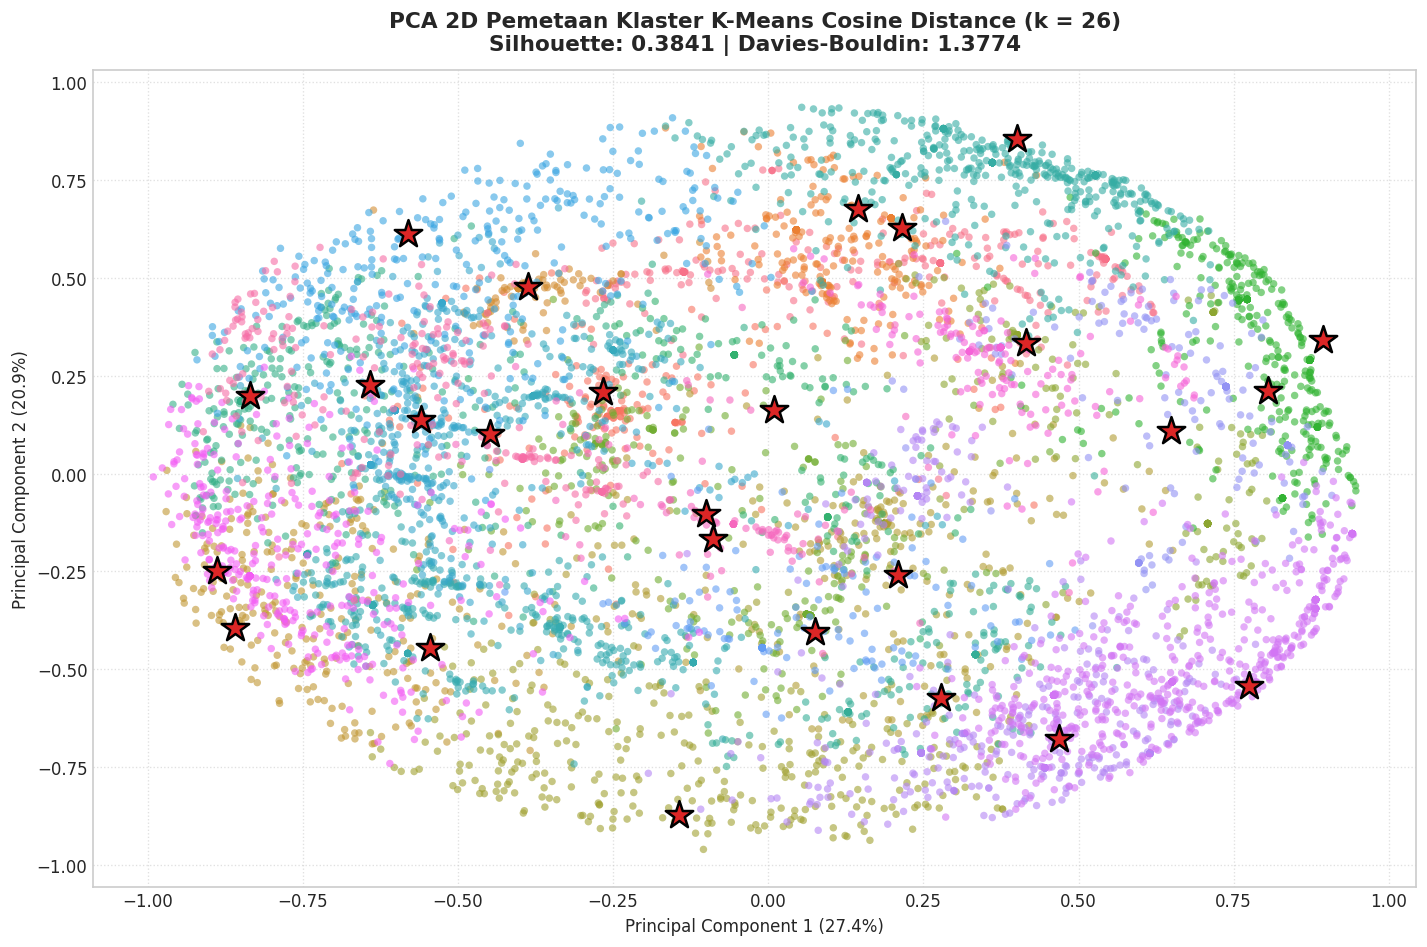

In [19]:
# =======================================================================
# 3.5 VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
print("[INFO] Membangun visualisasi PCA 2D...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_norm)
centroids_pca = pca.transform(model_cosine.centroids)

plt.figure(figsize=(12, 8))
palette = sns.color_palette("husl", optimal_k)

for k in range(optimal_k):
    mask = (model_cosine.labels_ == k)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k],
                label=f'Klaster {k}' if optimal_k <= 10 else None, alpha=0.6, s=20, edgecolors='none')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='*', s=300, c='#DC2626',
            edgecolor='black', linewidth=1.5, label='Centroids' if optimal_k <= 10 else None, zorder=10)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Cosine Distance (k = {optimal_k})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
if optimal_k <= 10:
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_KMEANS, "cluster_cosine.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

---
# 📊 Tahap 4: Perbandingan K-Means (Euclidean vs Manhattan vs Cosine)

In [20]:
# =======================================================================
# 4.1 KOMPILASI HASIL EVALUASI DARI KETIGA METODE K-MEANS
# =======================================================================
files_km = {
    'Euclidean': os.path.join(OUTPUT_KMEANS, 'evaluasi_kmeans_euclidean.xlsx'),
    'Manhattan': os.path.join(OUTPUT_KMEANS, 'evaluasi_kmeans_manhattan.xlsx'),
    'Cosine': os.path.join(OUTPUT_KMEANS, 'evaluasi_kmeans_cosine.xlsx')
}

summary_frames_km = []
data_frames_km = {}

for name, filepath in files_km.items():
    df_summary = pd.read_excel(filepath, sheet_name='Ringkasan_Evaluasi')
    summary_frames_km.append(df_summary)
    df_data = pd.read_excel(filepath, sheet_name='Data_Terklaster')
    data_frames_km[name] = df_data

df_comparison_km = pd.concat(summary_frames_km, ignore_index=True)

print("\n" + "="*90)
print("TABEL PERBANDINGAN METRIK EVALUASI K-MEANS")
print("="*90)
print(df_comparison_km.to_string(index=False))
print("="*90)

summary_csv = os.path.join(OUTPUT_KMEANS, 'metrics_comparison_summary.csv')
df_comparison_km.to_csv(summary_csv, index=False)


TABEL PERBANDINGAN METRIK EVALUASI K-MEANS
            Distance Metric  Chosen k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SSE) (↓)  Objective Value (SAE) (↓)  Objective Value (Inertia) (↓)
    Euclidean Distance (L2)        26                0.2210                    1.4260                       477.33                 0.61520              36                  133048.52                        NaN                            NaN
    Manhattan Distance (L1)        26                0.2301                    1.4012                       494.70                 1.03678              32                        NaN                  175164.57                            NaN
Cosine Distance (Spherical)        26                0.3841                    1.3774                       534.52                 0.76735              39                        NaN                        NaN                        1060

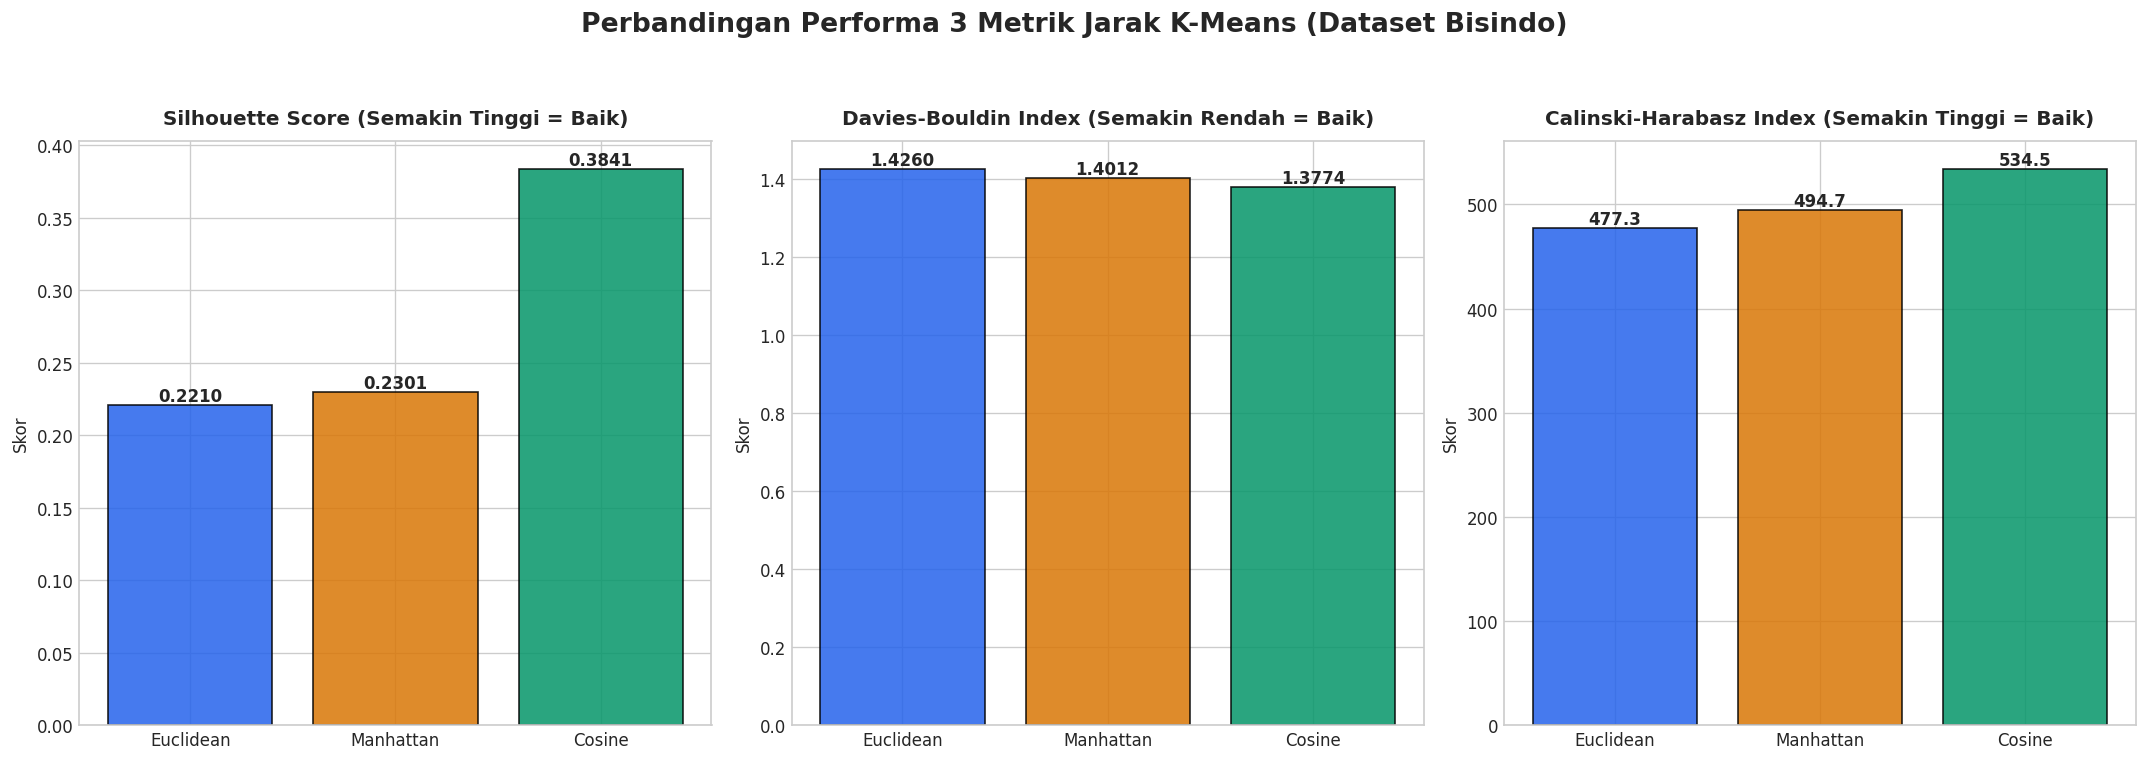

In [21]:
# =======================================================================
# 4.2 VISUALISASI PERBANDINGAN METRIK (BAR CHART)
# =======================================================================
metrics_to_plot = ['Silhouette Score (↑)', 'Davies–Bouldin Index (↓)', 'Calinski–Harabasz Index (↑)']
metric_titles = ['Silhouette Score (Semakin Tinggi = Baik)',
                 'Davies-Bouldin Index (Semakin Rendah = Baik)',
                 'Calinski-Harabasz Index (Semakin Tinggi = Baik)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2563EB', '#D97706', '#059669']

for i, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[i]
    bars = ax.bar(df_comparison_km['Distance Metric'].apply(lambda x: x.split()[0]),
                  df_comparison_km[metric], color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Skor')
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}' if yval < 10 else f'{yval:.1f}',
                ha='center', va='bottom', fontweight='bold')

plt.suptitle('Perbandingan Performa 3 Metrik Jarak K-Means (Dataset Bisindo)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()

barchart_path = os.path.join(OUTPUT_KMEANS, "metrics_comparison_barchart.png")
plt.savefig(barchart_path, dpi=300, bbox_inches='tight')
plt.show()

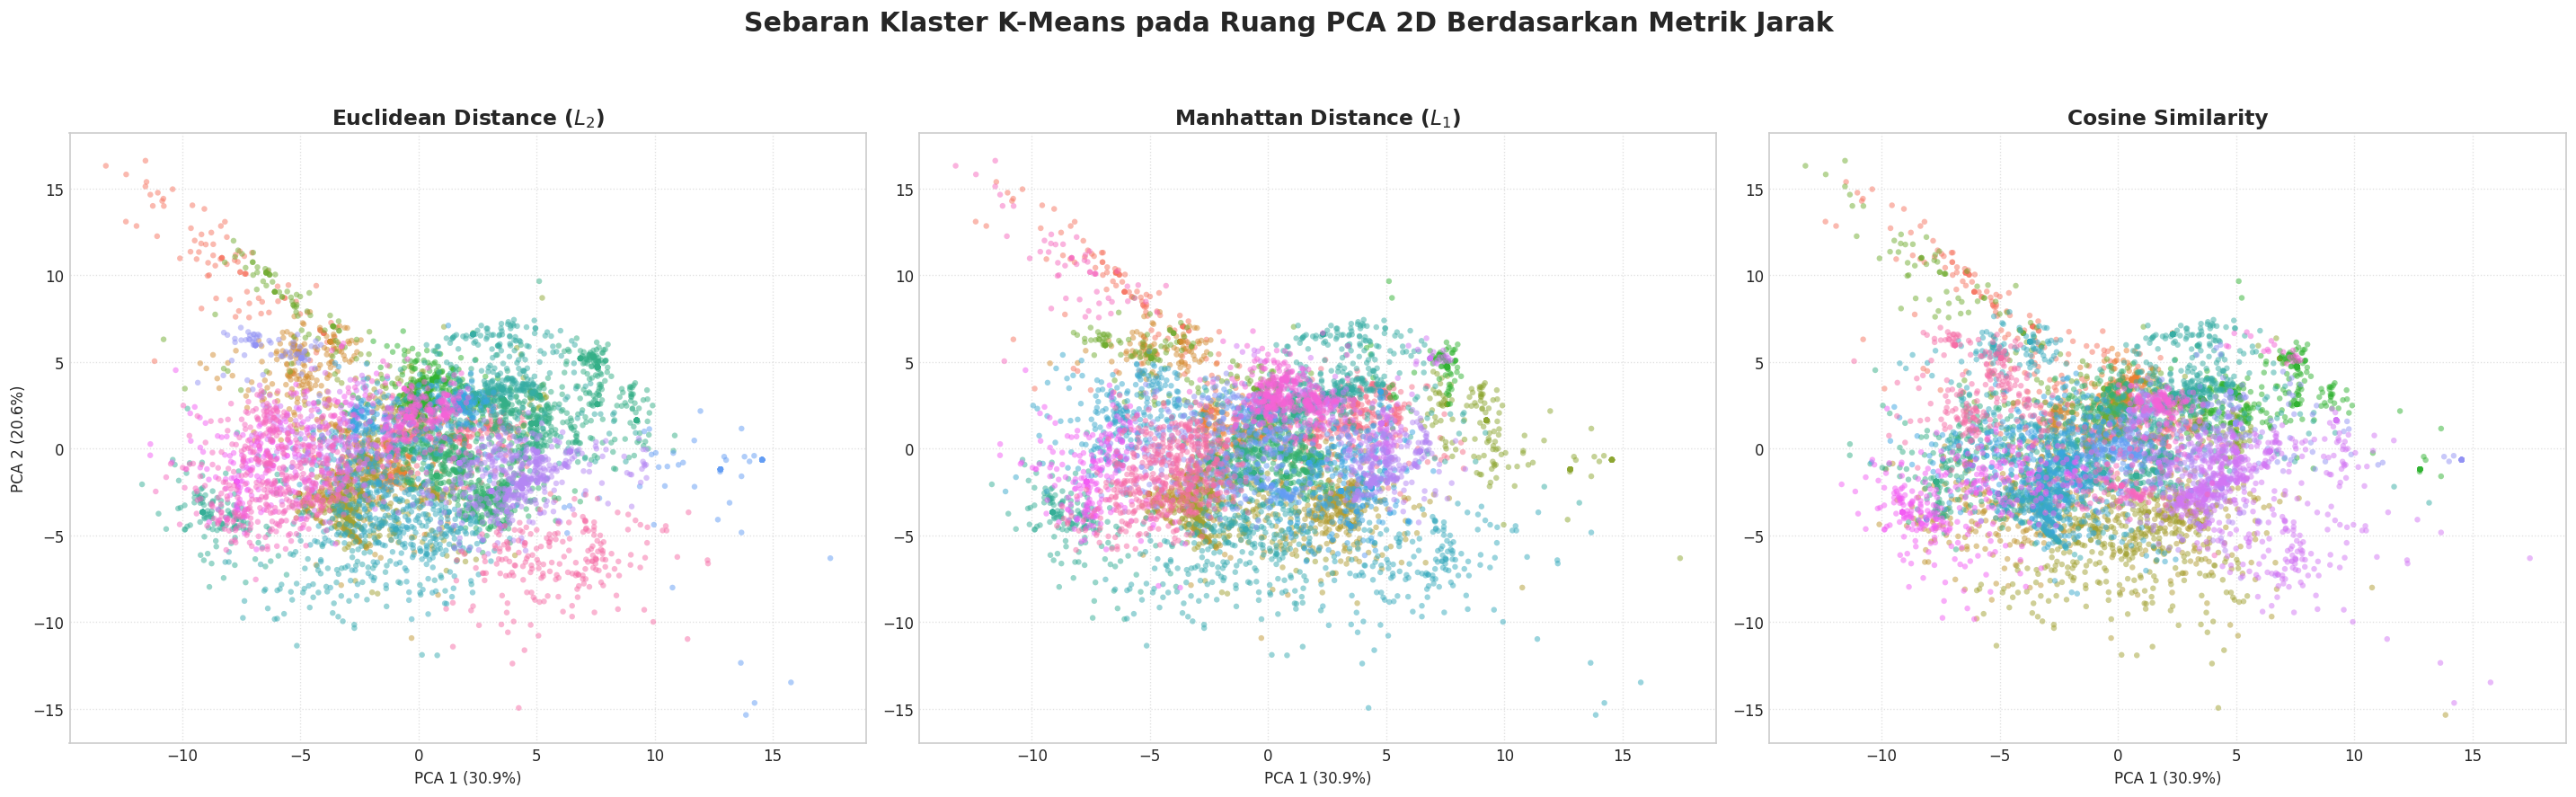

In [22]:
# =======================================================================
# 4.3 VISUALISASI PEMETAAN KLASTER PCA 2D (SIDE-BY-SIDE)
# =======================================================================
df_raw_km = data_frames_km['Euclidean']
cols_to_drop = ['label', 'filename'] + [c for c in df_raw_km.columns if 'Cluster_' in c]
df_features_km = df_raw_km.drop(columns=cols_to_drop)

scaler = StandardScaler()
X_scaled_km = scaler.fit_transform(df_features_km.values)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_km = pca.fit_transform(X_scaled_km)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
cluster_cols = ['Cluster_Euclidean', 'Cluster_Manhattan', 'Cluster_Cosine']
titles = ['Euclidean Distance ($L_2$)', 'Manhattan Distance ($L_1$)', 'Cosine Similarity']
palettes = sns.color_palette("husl", 26)

for i, (col, title) in enumerate(zip(cluster_cols, titles)):
    ax = axes[i]
    labels_km = data_frames_km[list(data_frames_km.keys())[i]][col]
    for k in range(26):
        mask = (labels_km == k)
        ax.scatter(X_pca_km[mask, 0], X_pca_km[mask, 1], color=palettes[k], alpha=0.5, s=15, edgecolors='none')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    if i == 0:
        ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Sebaran Klaster K-Means pada Ruang PCA 2D Berdasarkan Metrik Jarak', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

pca_comparison_path = os.path.join(OUTPUT_KMEANS, "cluster_comparison_pca2d.png")
plt.savefig(pca_comparison_path, dpi=300, bbox_inches='tight')
plt.show()

---
# 📊 Tahap 5: DBSCAN Clustering - Euclidean Distance ($L_2$ Norm)

## 📐 Konsep DBSCAN
1. **$\epsilon$-Neighborhood:** $N_\epsilon(p) = \{q \in D \mid d(p, q) \le \epsilon\}$
2. **Core Point:** $|N_\epsilon(p)| \ge \text{min\_samples}$
3. **Noise:** Titik yang tidak density-reachable dari core point manapun.

In [23]:
# =======================================================================
# 5.1 SETUP DBSCAN IMPORTS
# =======================================================================
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Reload standard scaled data
df_raw = pd.read_csv(DATASET_CSV)
cols_to_drop = ['label', 'filename']
df_features = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print(f"[DATA] Fitur siap untuk DBSCAN ({X_scaled.shape[1]} dimensi)")

[DATA] Fitur siap untuk DBSCAN (63 dimensi)


[INFO] Menghitung jarak ke k-Nearest Neighbors untuk estimasi Epsilon...
[SIMPAN] K-Distance graph disimpan ke: '/content/output/outputDBScan/kdistance_euclidean.png'


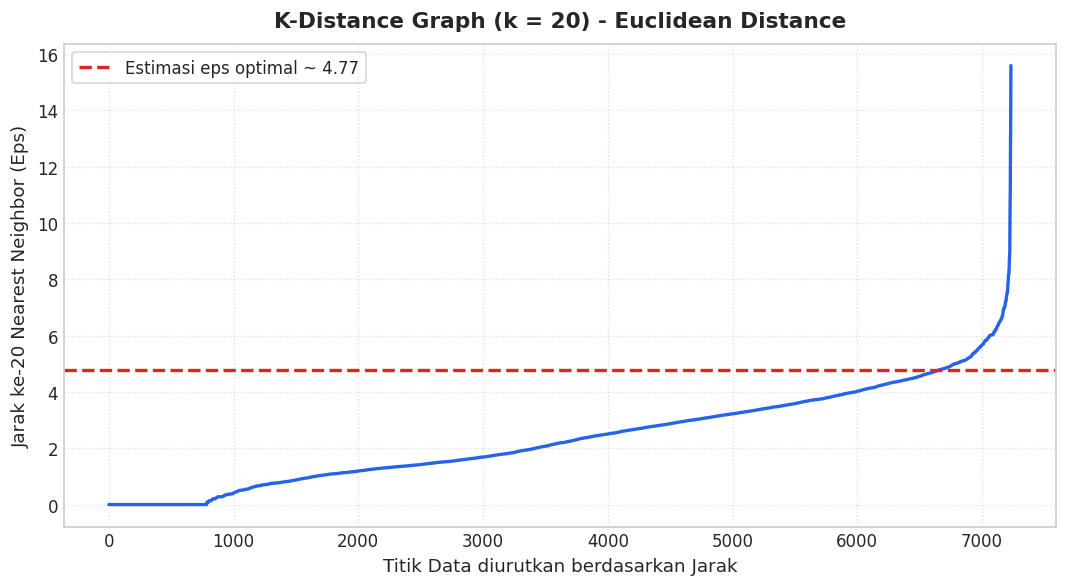

[INFO] Menjalankan DBSCAN dengan Eps=4.77 dan min_samples=20...
[HASIL] Terbentuk 2 klaster. Noise: 150 titik (2.1%).

TABEL EVALUASI DBSCAN EUCLIDEAN
Algorithm         Distance Metric   Eps  Min_Samples  Total Clusters  Noise Points  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)
   DBSCAN Euclidean Distance (L2) 4.773           20               2           150                 0.318                    0.5902                        67.72                 0.38413
[SIMPAN] Hasil evaluasi disimpan ke: '/content/output/outputDBScan/evaluasi_dbscan_euclidean.xlsx'


In [24]:
# =======================================================================
# 5.2 K-DISTANCE GRAPH & DBSCAN EUCLIDEAN
# =======================================================================
MIN_SAMPLES = 20

print("[INFO] Menghitung jarak ke k-Nearest Neighbors untuk estimasi Epsilon...")
k = MIN_SAMPLES
nearest_neighbors = NearestNeighbors(n_neighbors=k, metric='euclidean')
neighbors = nearest_neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='#2563EB', linewidth=2)
plt.title(f'K-Distance Graph (k = {MIN_SAMPLES}) - Euclidean Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik Data diurutkan berdasarkan Jarak', fontsize=11)
plt.ylabel(f'Jarak ke-{k} Nearest Neighbor (Eps)', fontsize=11)

optimal_eps_euc = np.percentile(k_distances, 92)
plt.axhline(y=optimal_eps_euc, color='#DC2626', linestyle='--', linewidth=2, label=f'Estimasi eps optimal ~ {optimal_eps_euc:.2f}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DBSCAN, "kdistance_euclidean.png")
plt.savefig(kdist_path, dpi=300)
print(f"[SIMPAN] K-Distance graph disimpan ke: '{kdist_path}'")
plt.show()

# DBSCAN Execution
print(f"[INFO] Menjalankan DBSCAN dengan Eps={optimal_eps_euc:.2f} dan min_samples={MIN_SAMPLES}...")
start_time = time.perf_counter()
dbscan_euc = DBSCAN(eps=optimal_eps_euc, min_samples=MIN_SAMPLES, metric='euclidean')
labels_db_euc = dbscan_euc.fit_predict(X_scaled)
execution_time = time.perf_counter() - start_time

n_clusters_ = len(set(labels_db_euc)) - (1 if -1 in labels_db_euc else 0)
n_noise_ = list(labels_db_euc).count(-1)
print(f"[HASIL] Terbentuk {n_clusters_} klaster. Noise: {n_noise_} titik ({(n_noise_/len(labels_db_euc))*100:.1f}%).")

mask_no_noise = labels_db_euc != -1
X_core = X_scaled[mask_no_noise]
labels_core = labels_db_euc[mask_no_noise]

if n_clusters_ > 1 and len(X_core) > 0:
    sil_score = silhouette_score(X_core, labels_core, metric='euclidean')
    db_score_val = davies_bouldin_score(X_core, labels_core)
    ch_score = calinski_harabasz_score(X_core, labels_core)
else:
    sil_score, db_score_val, ch_score = 0.0, 0.0, 0.0

eval_df = pd.DataFrame([{
    'Algorithm': 'DBSCAN', 'Distance Metric': 'Euclidean Distance (L2)', 'Eps': round(optimal_eps_euc, 3),
    'Min_Samples': MIN_SAMPLES, 'Total Clusters': n_clusters_, 'Noise Points': n_noise_,
    'Silhouette Score (↑)': round(sil_score, 4), 'Davies–Bouldin Index (↓)': round(db_score_val, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2), 'Execution Time (s) (↓)': round(execution_time, 5)
}])

print("\n" + "="*90)
print("TABEL EVALUASI DBSCAN EUCLIDEAN")
print("="*90)
print(eval_df.to_string(index=False))
print("="*90)

excel_path = os.path.join(OUTPUT_DBSCAN, "evaluasi_dbscan_euclidean.xlsx")
df_clustered_db_euc = df_raw.copy()
df_clustered_db_euc['Cluster_DBSCAN_Euclidean'] = labels_db_euc

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered_db_euc.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi disimpan ke: '{excel_path}'")

[SIMPAN] Grafik disimpan ke: '/content/output/outputDBScan/cluster_dbscan_euclidean.png'


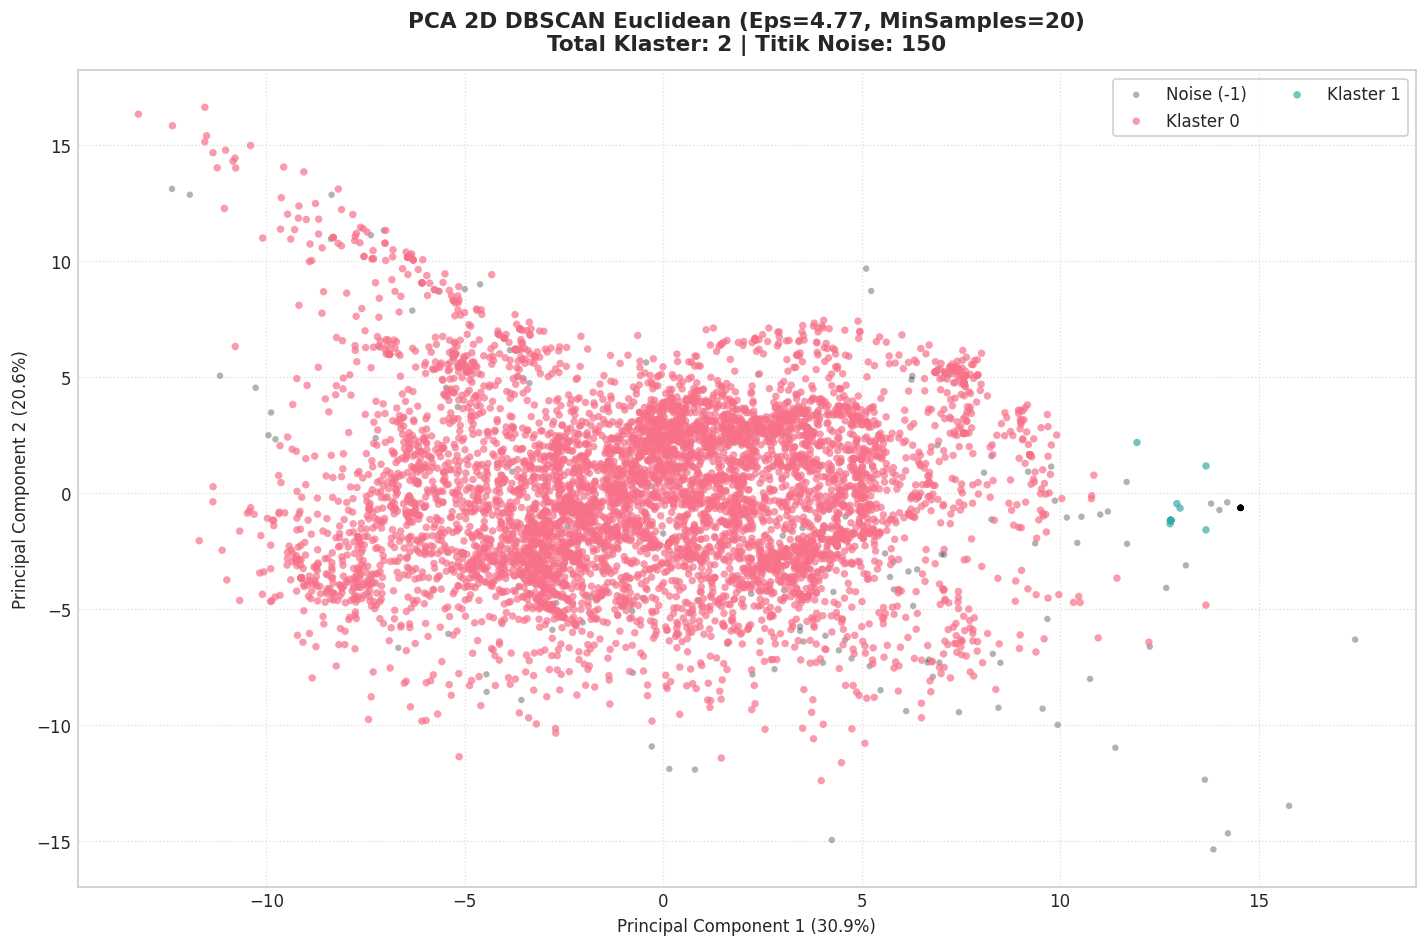

In [25]:
# =======================================================================
# 5.3 VISUALISASI PCA 2D DBSCAN EUCLIDEAN
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
noise_mask = (labels_db_euc == -1)
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], color='black', label='Noise (-1)', alpha=0.3, s=15, edgecolors='none', zorder=1)

palette = sns.color_palette("husl", n_clusters_)
for k_idx in range(n_clusters_):
    mask = (labels_db_euc == k_idx)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k_idx],
                label=f'Klaster {k_idx}' if n_clusters_ <= 15 else None, alpha=0.7, s=20, edgecolors='none', zorder=2)

plt.title(f'PCA 2D DBSCAN Euclidean (Eps={optimal_eps_euc:.2f}, MinSamples={MIN_SAMPLES})\n'
          f'Total Klaster: {n_clusters_} | Titik Noise: {n_noise_}', fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
if n_clusters_ <= 15:
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', ncol=2)
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DBSCAN, "cluster_dbscan_euclidean.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik disimpan ke: '{cluster_path}'")
plt.show()

---
# 📊 Tahap 6: DBSCAN Clustering - Manhattan Distance ($L_1$ Norm)

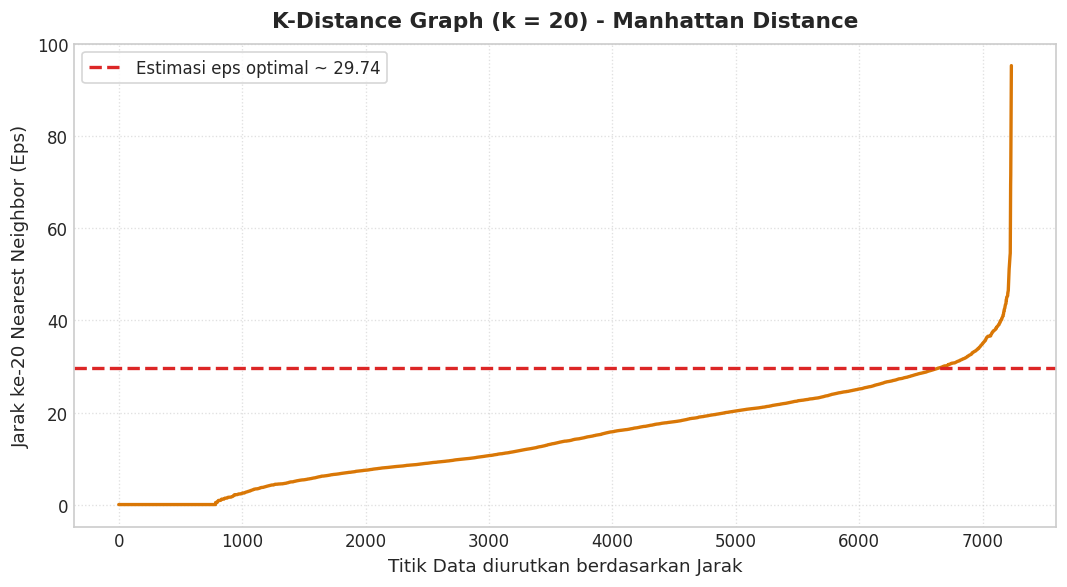

[HASIL] Terbentuk 2 klaster. Noise: 137 titik.
Algorithm         Distance Metric    Eps  Min_Samples  Total Clusters  Noise Points  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)
   DBSCAN Manhattan Distance (L1) 29.745           20               2           137                 0.343                    0.5906                        67.58                 4.02761
[SIMPAN] Hasil evaluasi disimpan ke: '/content/output/outputDBScan/evaluasi_dbscan_manhattan.xlsx'


In [26]:
# =======================================================================
# 6.1 K-DISTANCE GRAPH & DBSCAN MANHATTAN
# =======================================================================
nearest_neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='manhattan')
neighbors = nearest_neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, MIN_SAMPLES-1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='#D97706', linewidth=2)
plt.title(f'K-Distance Graph (k = {MIN_SAMPLES}) - Manhattan Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik Data diurutkan berdasarkan Jarak', fontsize=11)
plt.ylabel(f'Jarak ke-{MIN_SAMPLES} Nearest Neighbor (Eps)', fontsize=11)

optimal_eps_man = np.percentile(k_distances, 92)
plt.axhline(y=optimal_eps_man, color='#DC2626', linestyle='--', linewidth=2, label=f'Estimasi eps optimal ~ {optimal_eps_man:.2f}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DBSCAN, "kdistance_manhattan.png")
plt.savefig(kdist_path, dpi=300)
plt.show()

# DBSCAN Execution
start_time = time.perf_counter()
dbscan_man = DBSCAN(eps=optimal_eps_man, min_samples=MIN_SAMPLES, metric='manhattan')
labels_db_man = dbscan_man.fit_predict(X_scaled)
execution_time = time.perf_counter() - start_time

n_clusters_ = len(set(labels_db_man)) - (1 if -1 in labels_db_man else 0)
n_noise_ = list(labels_db_man).count(-1)
print(f"[HASIL] Terbentuk {n_clusters_} klaster. Noise: {n_noise_} titik.")

mask_no_noise = labels_db_man != -1
X_core = X_scaled[mask_no_noise]
labels_core = labels_db_man[mask_no_noise]

if n_clusters_ > 1 and len(X_core) > 0:
    sil_score = silhouette_score(X_core, labels_core, metric='manhattan')
    db_score_val = davies_bouldin_score(X_core, labels_core)
    ch_score = calinski_harabasz_score(X_core, labels_core)
else:
    sil_score, db_score_val, ch_score = 0.0, 0.0, 0.0

eval_df = pd.DataFrame([{
    'Algorithm': 'DBSCAN', 'Distance Metric': 'Manhattan Distance (L1)', 'Eps': round(optimal_eps_man, 3),
    'Min_Samples': MIN_SAMPLES, 'Total Clusters': n_clusters_, 'Noise Points': n_noise_,
    'Silhouette Score (↑)': round(sil_score, 4), 'Davies–Bouldin Index (↓)': round(db_score_val, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2), 'Execution Time (s) (↓)': round(execution_time, 5)
}])
print(eval_df.to_string(index=False))

excel_path = os.path.join(OUTPUT_DBSCAN, "evaluasi_dbscan_manhattan.xlsx")
df_clustered_db_man = df_raw.copy()
df_clustered_db_man['Cluster_DBSCAN_Manhattan'] = labels_db_man

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered_db_man.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi disimpan ke: '{excel_path}'")

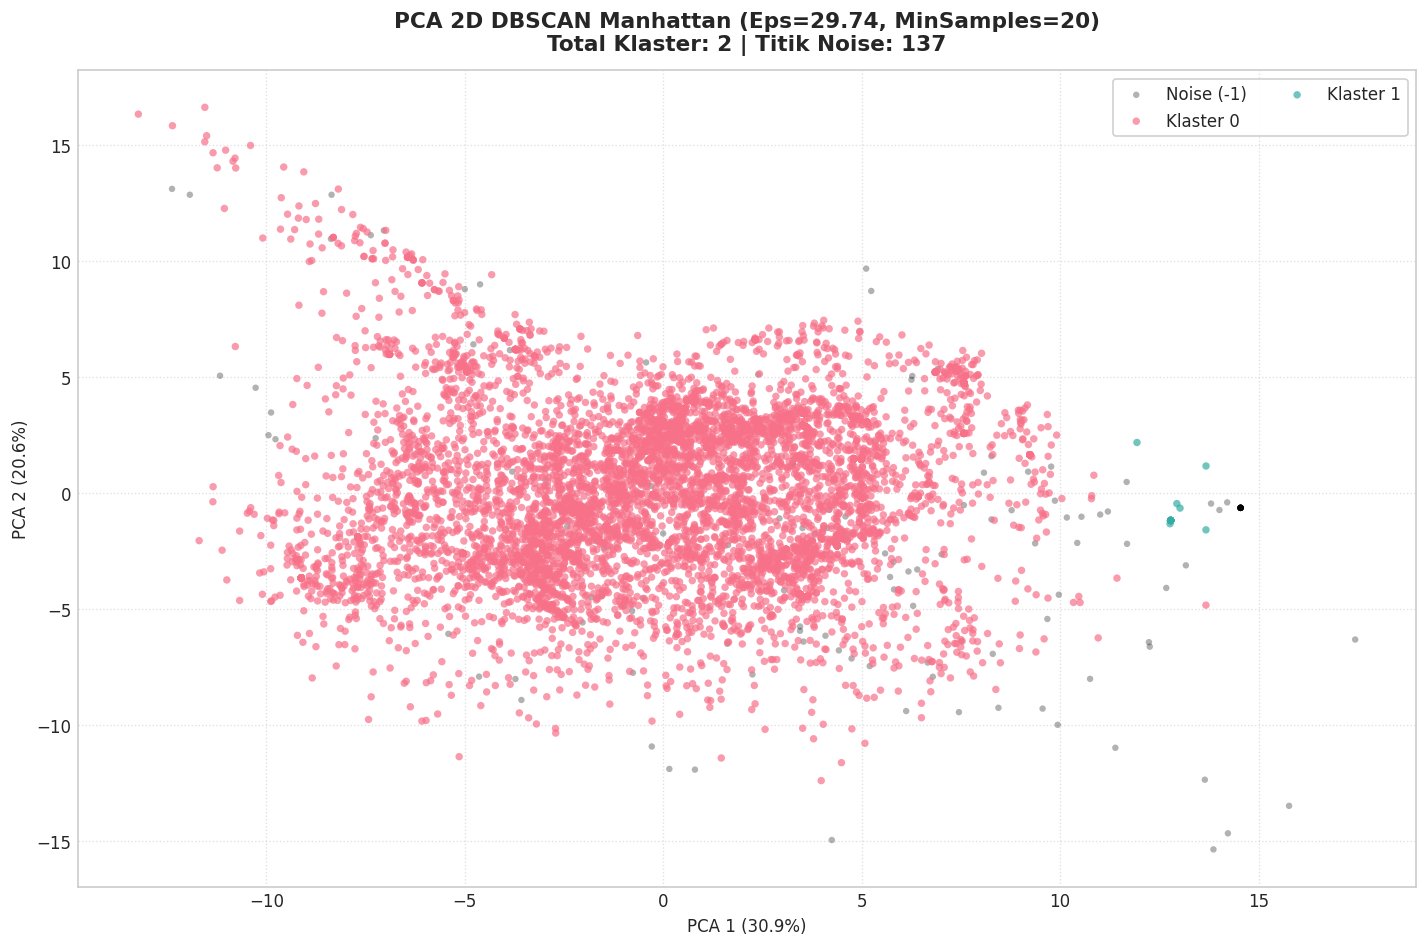

In [27]:
# =======================================================================
# 6.2 VISUALISASI PCA 2D DBSCAN MANHATTAN
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
noise_mask = (labels_db_man == -1)
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], color='black', label='Noise (-1)', alpha=0.3, s=15, edgecolors='none', zorder=1)
palette = sns.color_palette("husl", max(1, n_clusters_))
for k_idx in range(n_clusters_):
    mask = (labels_db_man == k_idx)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k_idx],
                label=f'Klaster {k_idx}' if n_clusters_ <= 15 else None, alpha=0.7, s=20, edgecolors='none', zorder=2)
plt.title(f'PCA 2D DBSCAN Manhattan (Eps={optimal_eps_man:.2f}, MinSamples={MIN_SAMPLES})\n'
          f'Total Klaster: {n_clusters_} | Titik Noise: {n_noise_}', fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
if 1 <= n_clusters_ <= 15:
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', ncol=2)
plt.tight_layout()
cluster_path = os.path.join(OUTPUT_DBSCAN, "cluster_dbscan_manhattan.png")
plt.savefig(cluster_path, dpi=300)
plt.show()

---
# 📊 Tahap 7: DBSCAN Clustering - Cosine Distance (Spherical)

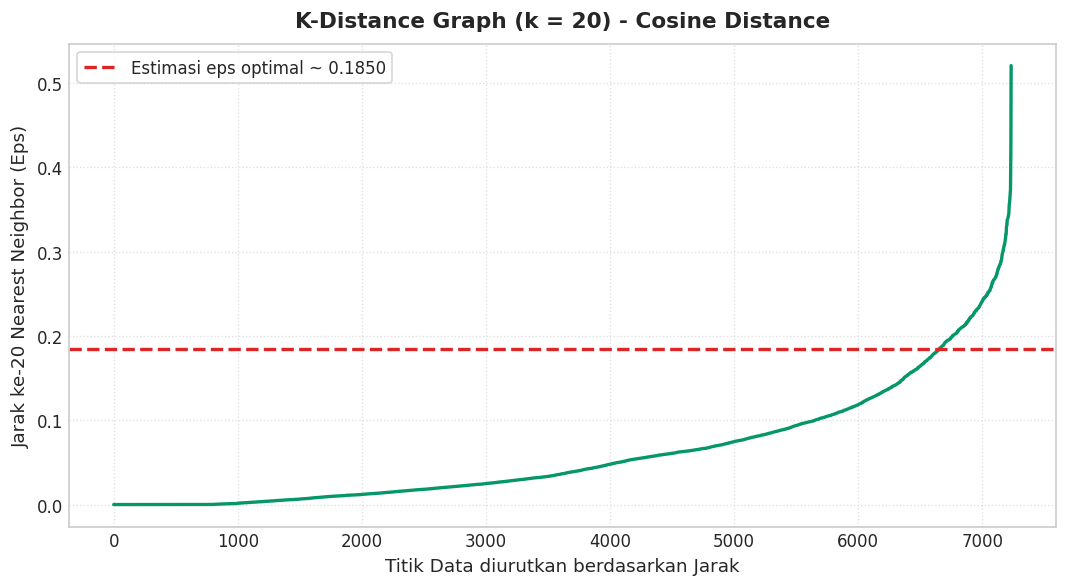

[HASIL] Terbentuk 6 klaster. Noise: 134 titik.
Algorithm             Distance Metric   Eps  Min_Samples  Total Clusters  Noise Points  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)
   DBSCAN Cosine Distance (Spherical) 0.185           20               6           134               -0.2339                    1.3573                       103.44                 0.85861
[SIMPAN] Hasil evaluasi disimpan ke: '/content/output/outputDBScan/evaluasi_dbscan_cosine.xlsx'


In [28]:
# =======================================================================
# 7.1 PEMUATAN DATASET L2-NORMALIZED & K-DISTANCE GRAPH COSINE
# =======================================================================
from sklearn.preprocessing import Normalizer

scaler = StandardScaler()
X_std = scaler.fit_transform(df_features.values)
normalizer = Normalizer(norm='l2')
X_norm_db = normalizer.fit_transform(X_std)

nearest_neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='cosine')
neighbors = nearest_neighbors.fit(X_norm_db)
distances, indices = neighbors.kneighbors(X_norm_db)
k_distances = np.sort(distances[:, MIN_SAMPLES-1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='#059669', linewidth=2)
plt.title(f'K-Distance Graph (k = {MIN_SAMPLES}) - Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik Data diurutkan berdasarkan Jarak', fontsize=11)
plt.ylabel(f'Jarak ke-{MIN_SAMPLES} Nearest Neighbor (Eps)', fontsize=11)

optimal_eps_cos = np.percentile(k_distances, 92)
plt.axhline(y=optimal_eps_cos, color='#DC2626', linestyle='--', linewidth=2, label=f'Estimasi eps optimal ~ {optimal_eps_cos:.4f}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DBSCAN, "kdistance_cosine.png")
plt.savefig(kdist_path, dpi=300)
plt.show()

# DBSCAN Execution
start_time = time.perf_counter()
dbscan_cos = DBSCAN(eps=optimal_eps_cos, min_samples=MIN_SAMPLES, metric='cosine')
labels_db_cos = dbscan_cos.fit_predict(X_norm_db)
execution_time = time.perf_counter() - start_time

n_clusters_ = len(set(labels_db_cos)) - (1 if -1 in labels_db_cos else 0)
n_noise_ = list(labels_db_cos).count(-1)
print(f"[HASIL] Terbentuk {n_clusters_} klaster. Noise: {n_noise_} titik.")

mask_no_noise = labels_db_cos != -1
X_core = X_norm_db[mask_no_noise]
labels_core = labels_db_cos[mask_no_noise]

if n_clusters_ > 1 and len(X_core) > 0:
    sil_score = silhouette_score(X_core, labels_core, metric='cosine')
    db_score_val = davies_bouldin_score(X_core, labels_core)
    ch_score = calinski_harabasz_score(X_core, labels_core)
else:
    sil_score, db_score_val, ch_score = 0.0, 0.0, 0.0

eval_df = pd.DataFrame([{
    'Algorithm': 'DBSCAN', 'Distance Metric': 'Cosine Distance (Spherical)', 'Eps': round(optimal_eps_cos, 4),
    'Min_Samples': MIN_SAMPLES, 'Total Clusters': n_clusters_, 'Noise Points': n_noise_,
    'Silhouette Score (↑)': round(sil_score, 4), 'Davies–Bouldin Index (↓)': round(db_score_val, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2), 'Execution Time (s) (↓)': round(execution_time, 5)
}])
print(eval_df.to_string(index=False))

excel_path = os.path.join(OUTPUT_DBSCAN, "evaluasi_dbscan_cosine.xlsx")
df_clustered_db_cos = df_raw.copy()
df_clustered_db_cos['Cluster_DBSCAN_Cosine'] = labels_db_cos

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered_db_cos.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi disimpan ke: '{excel_path}'")

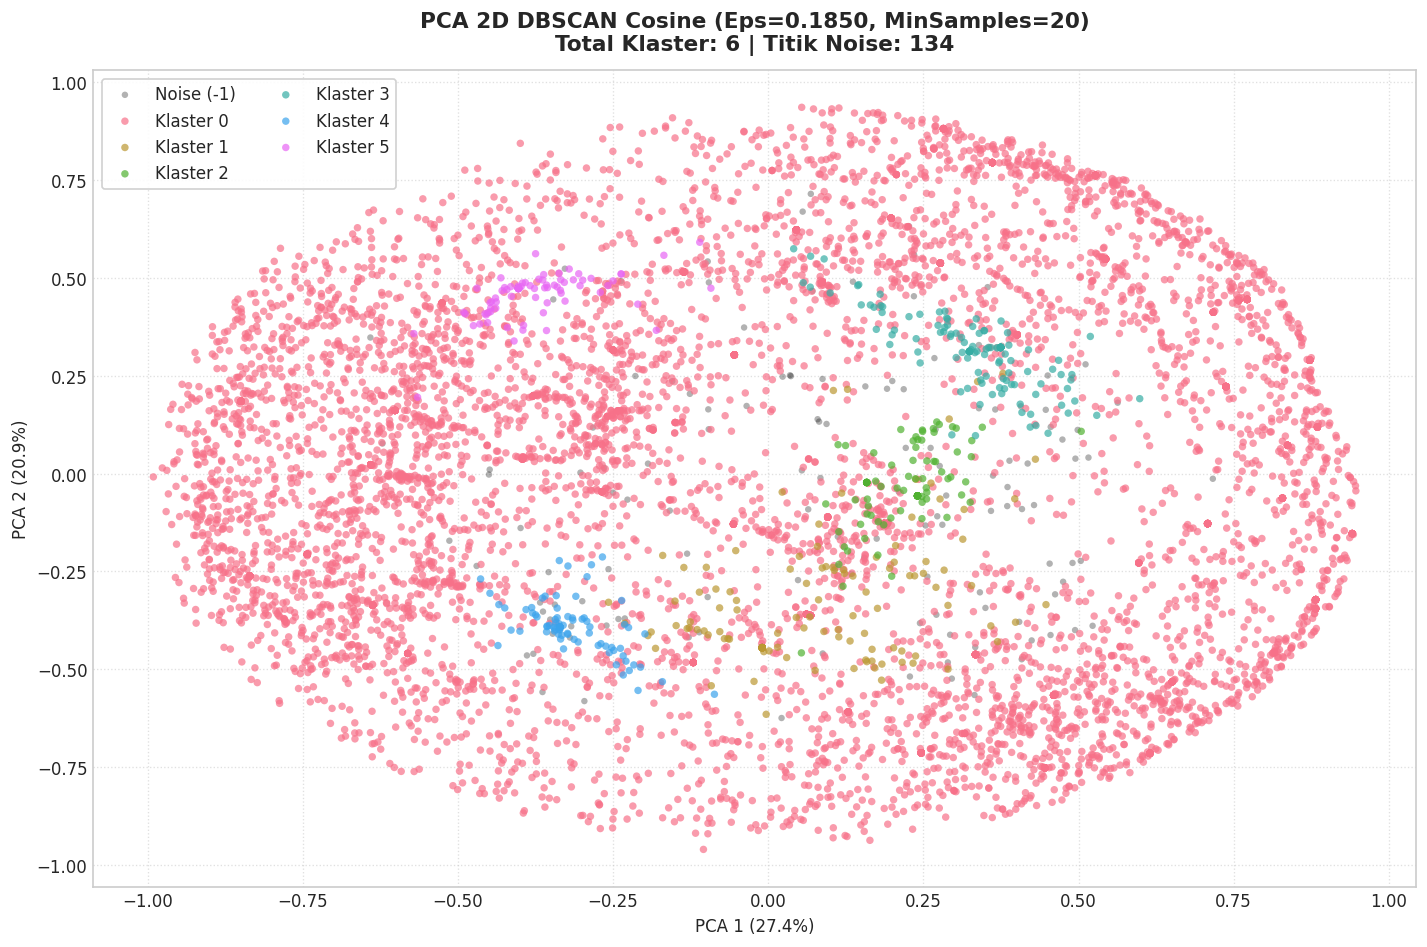

In [29]:
# =======================================================================
# 7.2 VISUALISASI PCA 2D DBSCAN COSINE
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_norm_db)

plt.figure(figsize=(12, 8))
noise_mask = (labels_db_cos == -1)
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], color='black', label='Noise (-1)', alpha=0.3, s=15, edgecolors='none', zorder=1)
palette = sns.color_palette("husl", max(1, n_clusters_))
for k_idx in range(n_clusters_):
    mask = (labels_db_cos == k_idx)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k_idx],
                label=f'Klaster {k_idx}' if n_clusters_ <= 15 else None, alpha=0.7, s=20, edgecolors='none', zorder=2)
plt.title(f'PCA 2D DBSCAN Cosine (Eps={optimal_eps_cos:.4f}, MinSamples={MIN_SAMPLES})\n'
          f'Total Klaster: {n_clusters_} | Titik Noise: {n_noise_}', fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
if 1 <= n_clusters_ <= 15:
    plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best', ncol=2)
plt.tight_layout()
cluster_path = os.path.join(OUTPUT_DBSCAN, "cluster_dbscan_cosine.png")
plt.savefig(cluster_path, dpi=300)
plt.show()

---
# 📊 Tahap 8: Perbandingan DBSCAN (Euclidean vs Manhattan vs Cosine)

In [30]:
# =======================================================================
# 8.1 KOMPILASI HASIL EVALUASI DARI KETIGA METODE DBSCAN
# =======================================================================
files_db = {
    'Euclidean': os.path.join(OUTPUT_DBSCAN, 'evaluasi_dbscan_euclidean.xlsx'),
    'Manhattan': os.path.join(OUTPUT_DBSCAN, 'evaluasi_dbscan_manhattan.xlsx'),
    'Cosine': os.path.join(OUTPUT_DBSCAN, 'evaluasi_dbscan_cosine.xlsx')
}

summary_frames_db = []
data_frames_db = {}

for name, filepath in files_db.items():
    df_summary = pd.read_excel(filepath, sheet_name='Ringkasan_Evaluasi')
    summary_frames_db.append(df_summary)
    df_data = pd.read_excel(filepath, sheet_name='Data_Terklaster')
    data_frames_db[name] = df_data

df_comparison_db = pd.concat(summary_frames_db, ignore_index=True)

print("\n" + "="*90)
print("TABEL PERBANDINGAN METRIK EVALUASI DBSCAN")
print("="*90)
print(df_comparison_db.to_string(index=False))
print("="*90)

summary_csv = os.path.join(OUTPUT_DBSCAN, 'metrics_comparison_summary.csv')
df_comparison_db.to_csv(summary_csv, index=False)


TABEL PERBANDINGAN METRIK EVALUASI DBSCAN
Algorithm             Distance Metric    Eps  Min_Samples  Total Clusters  Noise Points  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)
   DBSCAN     Euclidean Distance (L2)  4.773           20               2           150                0.3180                    0.5902                        67.72                 0.38413
   DBSCAN     Manhattan Distance (L1) 29.745           20               2           137                0.3430                    0.5906                        67.58                 4.02761
   DBSCAN Cosine Distance (Spherical)  0.185           20               6           134               -0.2339                    1.3573                       103.44                 0.85861


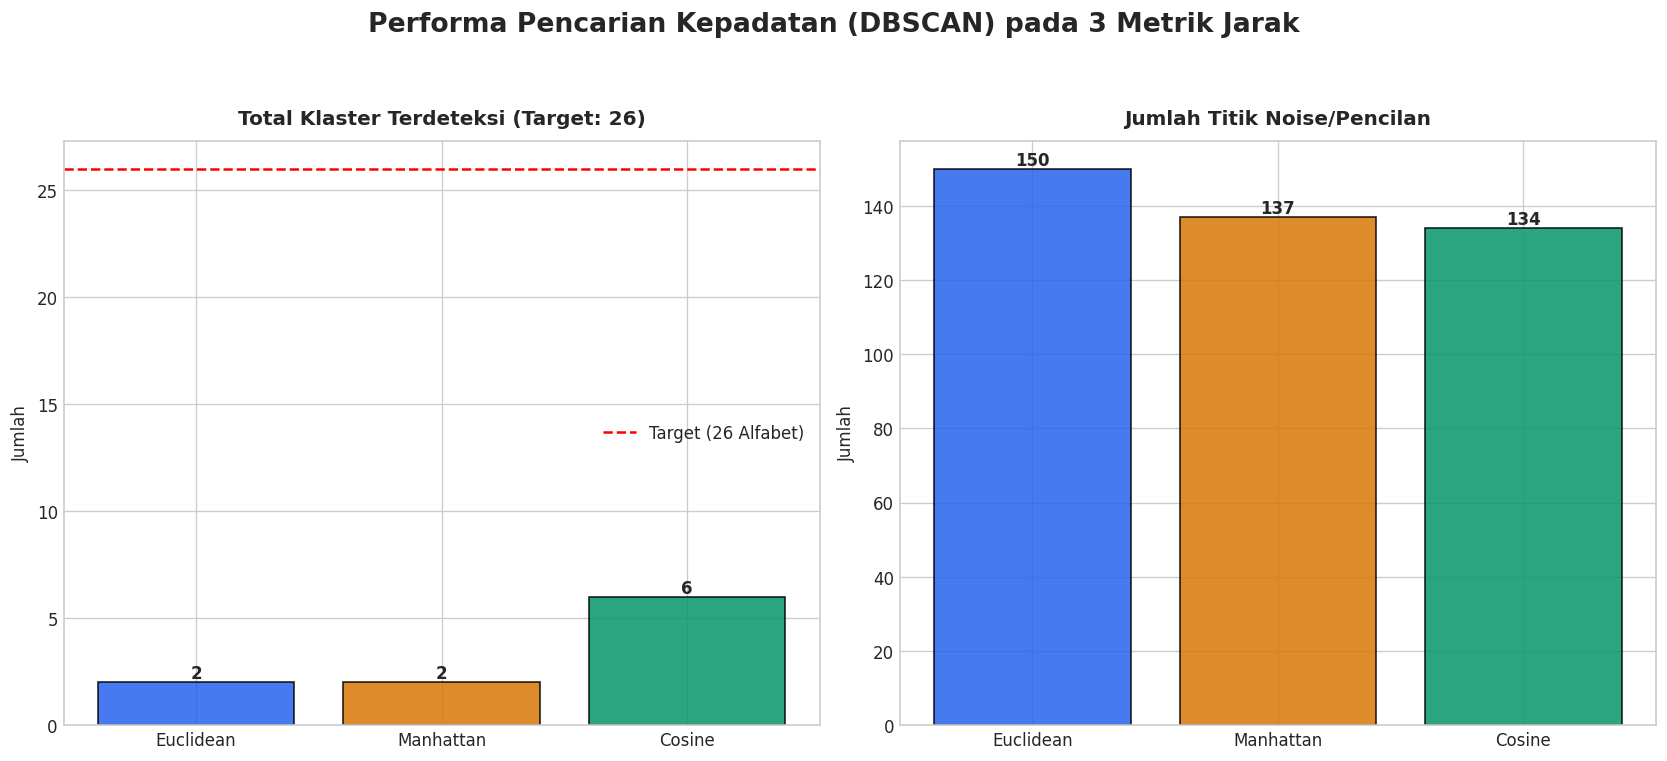

In [31]:
# =======================================================================
# 8.2 VISUALISASI PERBANDINGAN JUMLAH KLASTER & NOISE
# =======================================================================
metrics_to_plot = ['Total Clusters', 'Noise Points']
metric_titles = ['Total Klaster Terdeteksi (Target: 26)', 'Jumlah Titik Noise/Pencilan']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2563EB', '#D97706', '#059669']
labels_bar = [x.split()[0] for x in df_comparison_db['Distance Metric']]

for i, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[i]
    bars = ax.bar(labels_bar, df_comparison_db[metric], color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Jumlah')
    if metric == 'Total Clusters':
        ax.axhline(y=26, color='red', linestyle='--', linewidth=1.5, label='Target (26 Alfabet)')
        ax.legend()
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Performa Pencarian Kepadatan (DBSCAN) pada 3 Metrik Jarak', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()

barchart_path = os.path.join(OUTPUT_DBSCAN, "metrics_comparison_barchart.png")
plt.savefig(barchart_path, dpi=300, bbox_inches='tight')
plt.show()

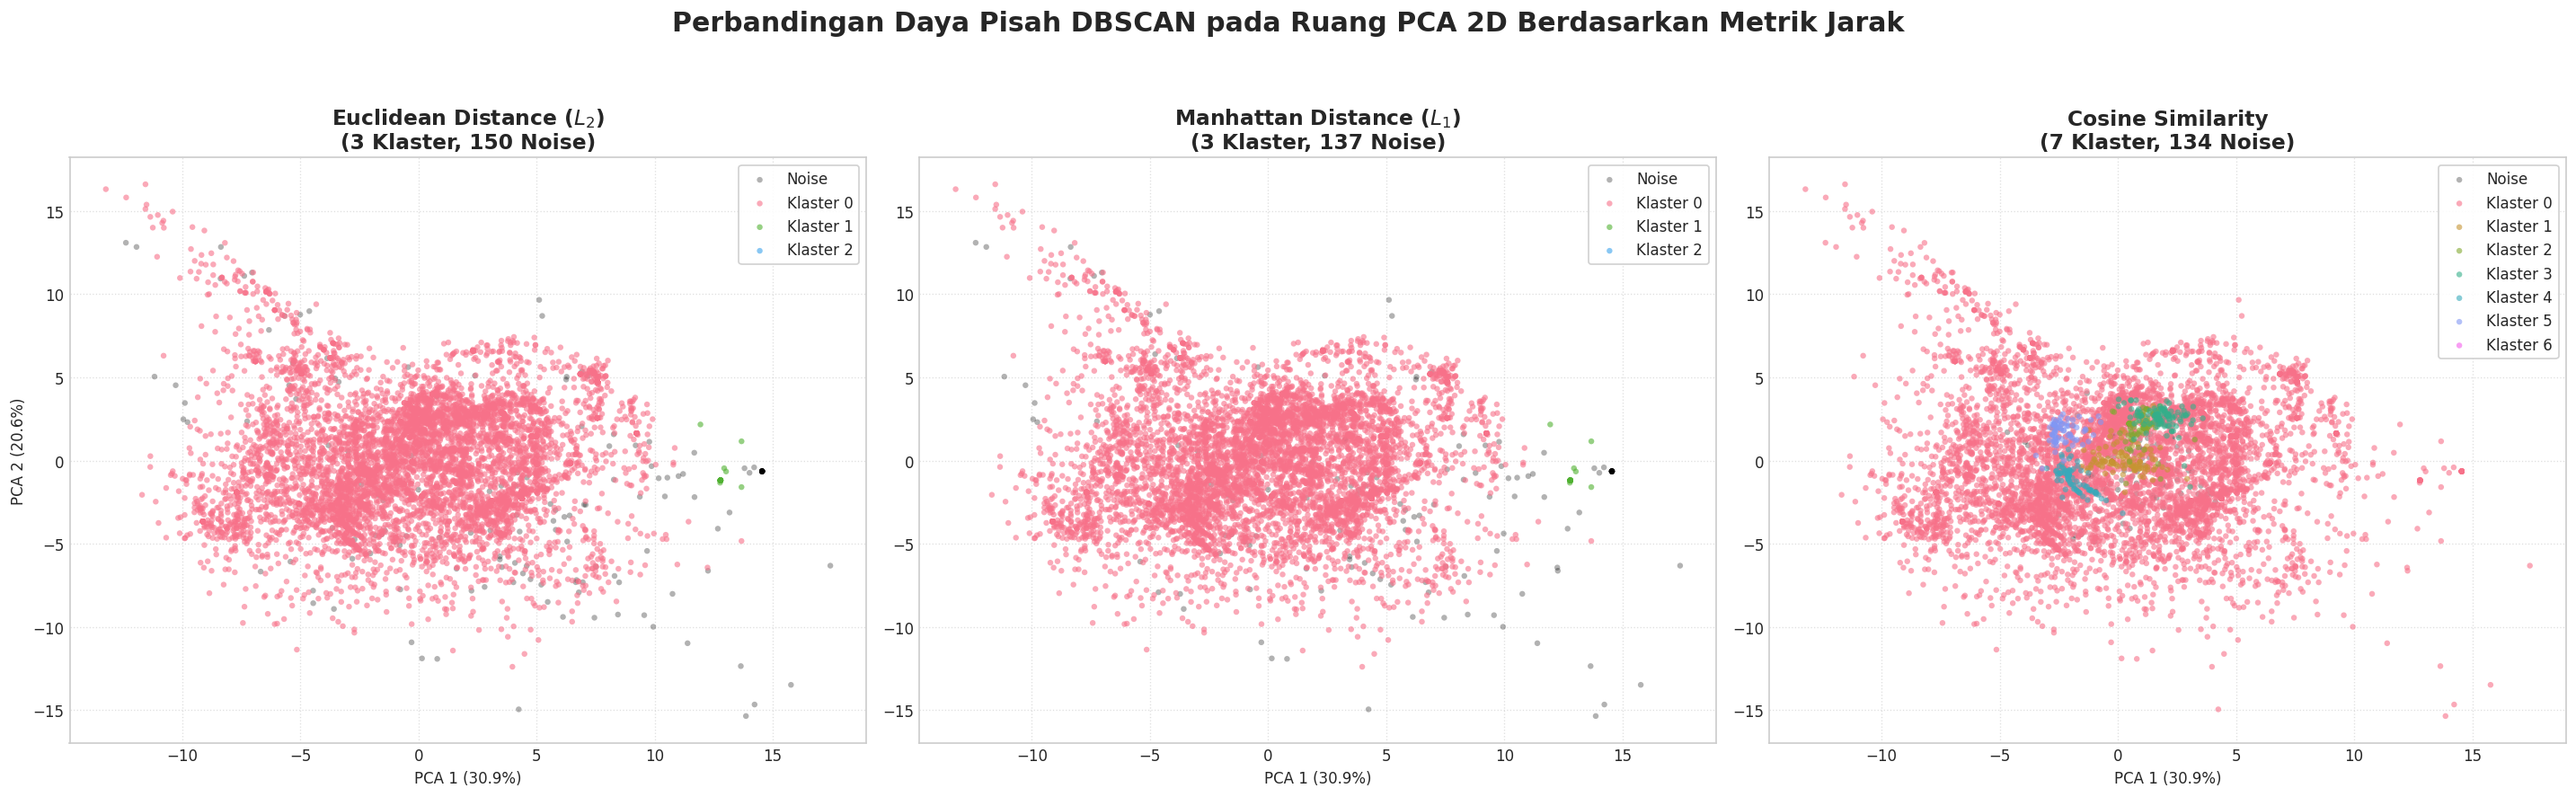

In [32]:
# =======================================================================
# 8.3 VISUALISASI PEMETAAN KLASTER PCA 2D (SIDE-BY-SIDE) DBSCAN
# =======================================================================
df_raw_db = data_frames_db['Euclidean']
cols_to_drop = ['label', 'filename'] + [c for c in df_raw_db.columns if 'Cluster_' in c]
df_features_db = df_raw_db.drop(columns=cols_to_drop)

scaler = StandardScaler()
X_scaled_db = scaler.fit_transform(df_features_db.values)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_db = pca.fit_transform(X_scaled_db)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
cluster_cols = ['Cluster_DBSCAN_Euclidean', 'Cluster_DBSCAN_Manhattan', 'Cluster_DBSCAN_Cosine']
titles = ['Euclidean Distance ($L_2$)', 'Manhattan Distance ($L_1$)', 'Cosine Similarity']

for i, (col, title) in enumerate(zip(cluster_cols, titles)):
    ax = axes[i]
    labels_db_vis = data_frames_db[list(data_frames_db.keys())[i]][col]
    n_clus = len(set(labels_db_vis)) - (1 if -1 in labels_db_vis else 0)
    palettes = sns.color_palette("husl", max(1, n_clus))
    noise_mask = (labels_db_vis == -1)
    ax.scatter(X_pca_db[noise_mask, 0], X_pca_db[noise_mask, 1], color='black', alpha=0.3, s=15, edgecolors='none', label='Noise')
    for k_idx in range(n_clus):
        mask = (labels_db_vis == k_idx)
        ax.scatter(X_pca_db[mask, 0], X_pca_db[mask, 1], color=palettes[k_idx], alpha=0.6, s=15, edgecolors='none',
                   label=f'Klaster {k_idx}' if n_clus <= 10 else None)
    ax.set_title(f'{title}\n({n_clus} Klaster, {sum(noise_mask)} Noise)', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    if i == 0:
        ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, linestyle=':', alpha=0.6)
    if n_clus <= 10:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')

plt.suptitle('Perbandingan Daya Pisah DBSCAN pada Ruang PCA 2D Berdasarkan Metrik Jarak', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
pca_comparison_path = os.path.join(OUTPUT_DBSCAN, "cluster_comparison_pca2d.png")
plt.savefig(pca_comparison_path, dpi=300, bbox_inches='tight')
plt.show()

---
# 🏆 Tahap 9: Komparasi Akhir 6 Model Klasterisasi & Kesimpulan

In [33]:
# =======================================================================
# 9.1 KOMPILASI SELURUH 6 HASIL EVALUASI MODEL & DATA KLASTER
# =======================================================================
files_all = {
    'K-Means Euclidean': os.path.join(OUTPUT_KMEANS, 'evaluasi_kmeans_euclidean.xlsx'),
    'K-Means Manhattan': os.path.join(OUTPUT_KMEANS, 'evaluasi_kmeans_manhattan.xlsx'),
    'K-Means Cosine'   : os.path.join(OUTPUT_KMEANS, 'evaluasi_kmeans_cosine.xlsx'),
    'DBSCAN Euclidean' : os.path.join(OUTPUT_DBSCAN, 'evaluasi_dbscan_euclidean.xlsx'),
    'DBSCAN Manhattan' : os.path.join(OUTPUT_DBSCAN, 'evaluasi_dbscan_manhattan.xlsx'),
    'DBSCAN Cosine'    : os.path.join(OUTPUT_DBSCAN, 'evaluasi_dbscan_cosine.xlsx'),
}

summary_frames_all = []
data_frames_all = {}

for name, filepath in files_all.items():
    df_summary = pd.read_excel(filepath, sheet_name='Ringkasan_Evaluasi')
    df_data = pd.read_excel(filepath, sheet_name='Data_Terklaster')
    data_frames_all[name] = df_data

    if 'Algorithm' not in df_summary.columns:
        df_summary.insert(0, 'Algorithm', 'K-Means')
        df_summary['Total Clusters'] = df_summary['Chosen k']
        df_summary['Noise Points'] = 0

    summary_frames_all.append(df_summary)

df_master = pd.concat(summary_frames_all, ignore_index=True)

cols_to_keep = ['Algorithm', 'Distance Metric', 'Total Clusters', 'Noise Points',
                'Silhouette Score (↑)', 'Davies–Bouldin Index (↓)', 'Execution Time (s) (↓)']
df_master_clean = df_master[[c for c in cols_to_keep if c in df_master.columns]]

print("\n" + "="*110)
print("TABEL MASTER: KOMPARASI 6 METODE KLASTERISASI BISINDO")
print("="*110)
print(df_master_clean.to_string(index=False))
print("="*110)

csv_path = os.path.join(OUTPUT_COMPARISON, 'master_comparison_metrics.csv')
df_master_clean.to_csv(csv_path, index=False)


TABEL MASTER: KOMPARASI 6 METODE KLASTERISASI BISINDO
Algorithm             Distance Metric  Total Clusters  Noise Points  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Execution Time (s) (↓)
  K-Means     Euclidean Distance (L2)              26             0                0.2210                    1.4260                 0.61520
  K-Means     Manhattan Distance (L1)              26             0                0.2301                    1.4012                 1.03678
  K-Means Cosine Distance (Spherical)              26             0                0.3841                    1.3774                 0.76735
   DBSCAN     Euclidean Distance (L2)               2           150                0.3180                    0.5902                 0.38413
   DBSCAN     Manhattan Distance (L1)               2           137                0.3430                    0.5906                 4.02761
   DBSCAN Cosine Distance (Spherical)               6           134               -0.2339                

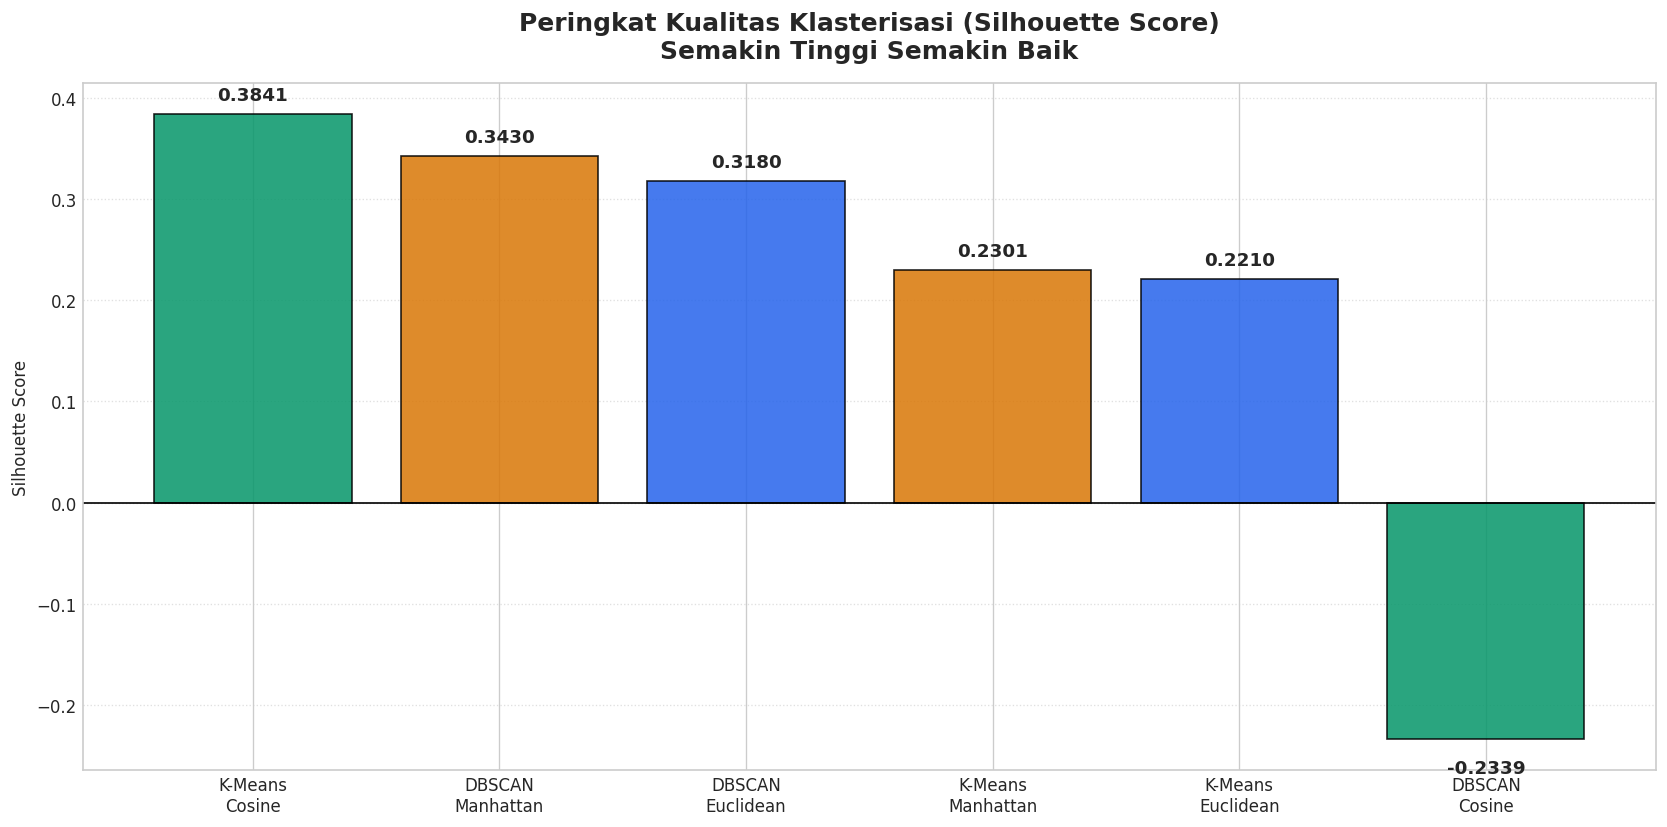

In [34]:
# =======================================================================
# 9.2 VISUALISASI PERINGKAT SILHOUETTE SCORE
# =======================================================================
df_master_clean['Model_Name'] = df_master_clean['Algorithm'] + "\n" + df_master_clean['Distance Metric'].apply(lambda x: x.split()[0])

plt.figure(figsize=(14, 7))
df_sorted_sil = df_master_clean.sort_values(by='Silhouette Score (↑)', ascending=False)
colors = ['#059669' if 'Cosine' in x else '#2563EB' if 'Euclidean' in x else '#D97706' for x in df_sorted_sil['Distance Metric']]

bars = plt.bar(df_sorted_sil['Model_Name'], df_sorted_sil['Silhouette Score (↑)'], color=colors, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01 if yval > 0 else yval - 0.02,
             f'{yval:.4f}', ha='center', va='bottom' if yval > 0 else 'top', fontweight='bold', fontsize=11)

plt.axhline(y=0, color='black', linewidth=1)
plt.title('Peringkat Kualitas Klasterisasi (Silhouette Score)\nSemakin Tinggi Semakin Baik', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Silhouette Score')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

sil_path = os.path.join(OUTPUT_COMPARISON, "master_silhouette_comparison.png")
plt.savefig(sil_path, dpi=300, bbox_inches='tight')
plt.show()

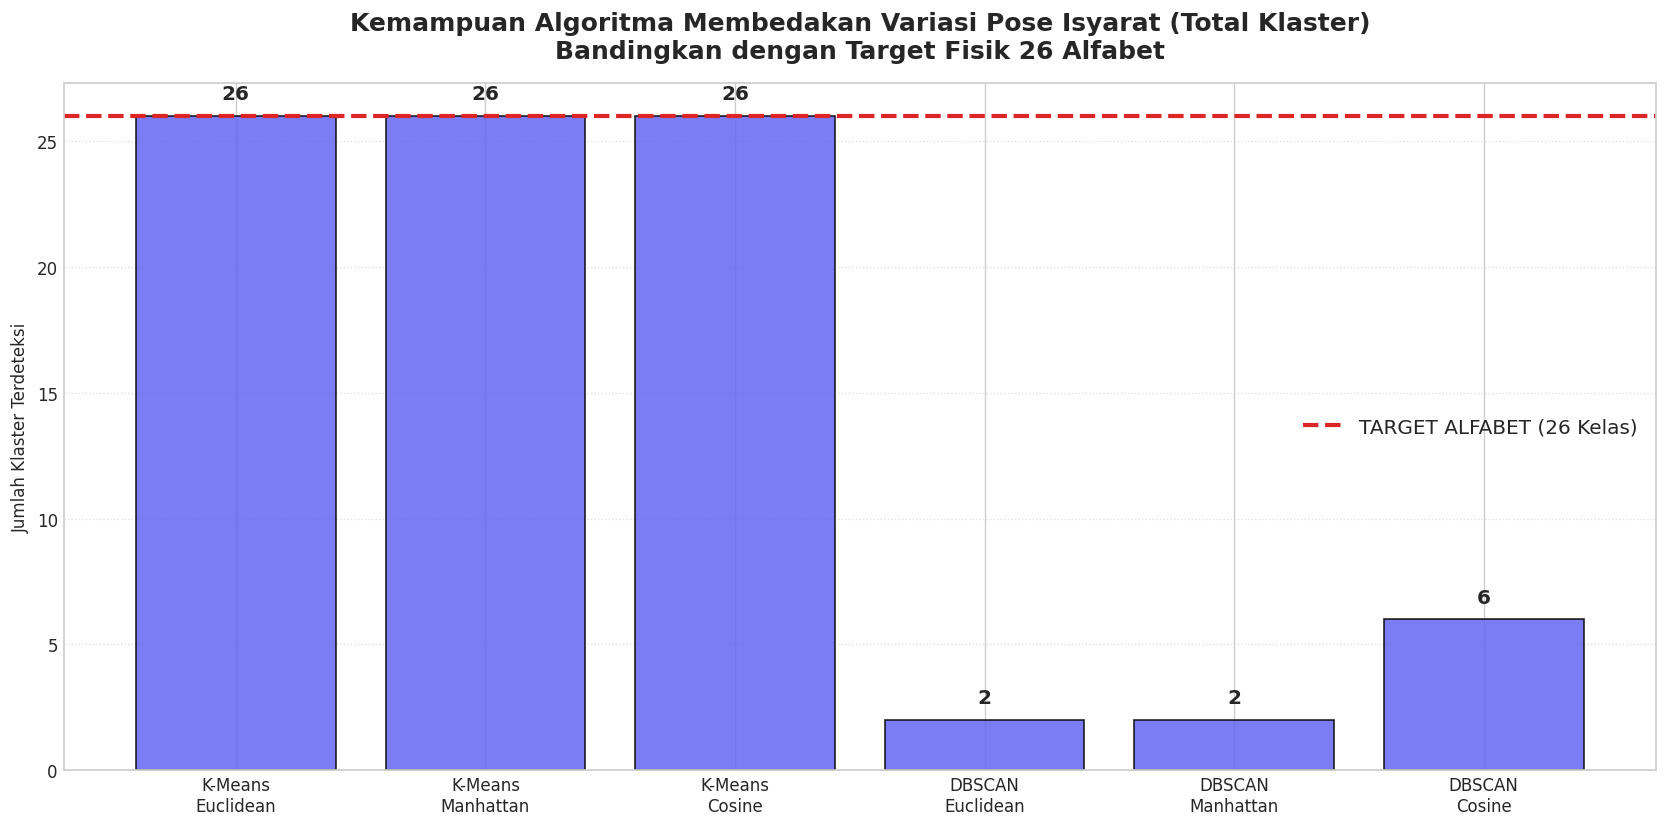

In [35]:
# =======================================================================
# 9.3 VISUALISASI KEMAMPUAN MENEMUKAN TARGET KELAS (26 ALFABET)
# =======================================================================
plt.figure(figsize=(14, 7))
bars2 = plt.bar(df_master_clean['Model_Name'], df_master_clean['Total Clusters'], color='#6366F1', edgecolor='black', alpha=0.85)

plt.axhline(y=26, color='#DC2626', linestyle='--', linewidth=2.5, label='TARGET ALFABET (26 Kelas)')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, str(int(yval)), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Kemampuan Algoritma Membedakan Variasi Pose Isyarat (Total Klaster)\nBandingkan dengan Target Fisik 26 Alfabet',
          fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Jumlah Klaster Terdeteksi')
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

clust_path = os.path.join(OUTPUT_COMPARISON, "master_cluster_count_comparison.png")
plt.savefig(clust_path, dpi=300, bbox_inches='tight')
plt.show()

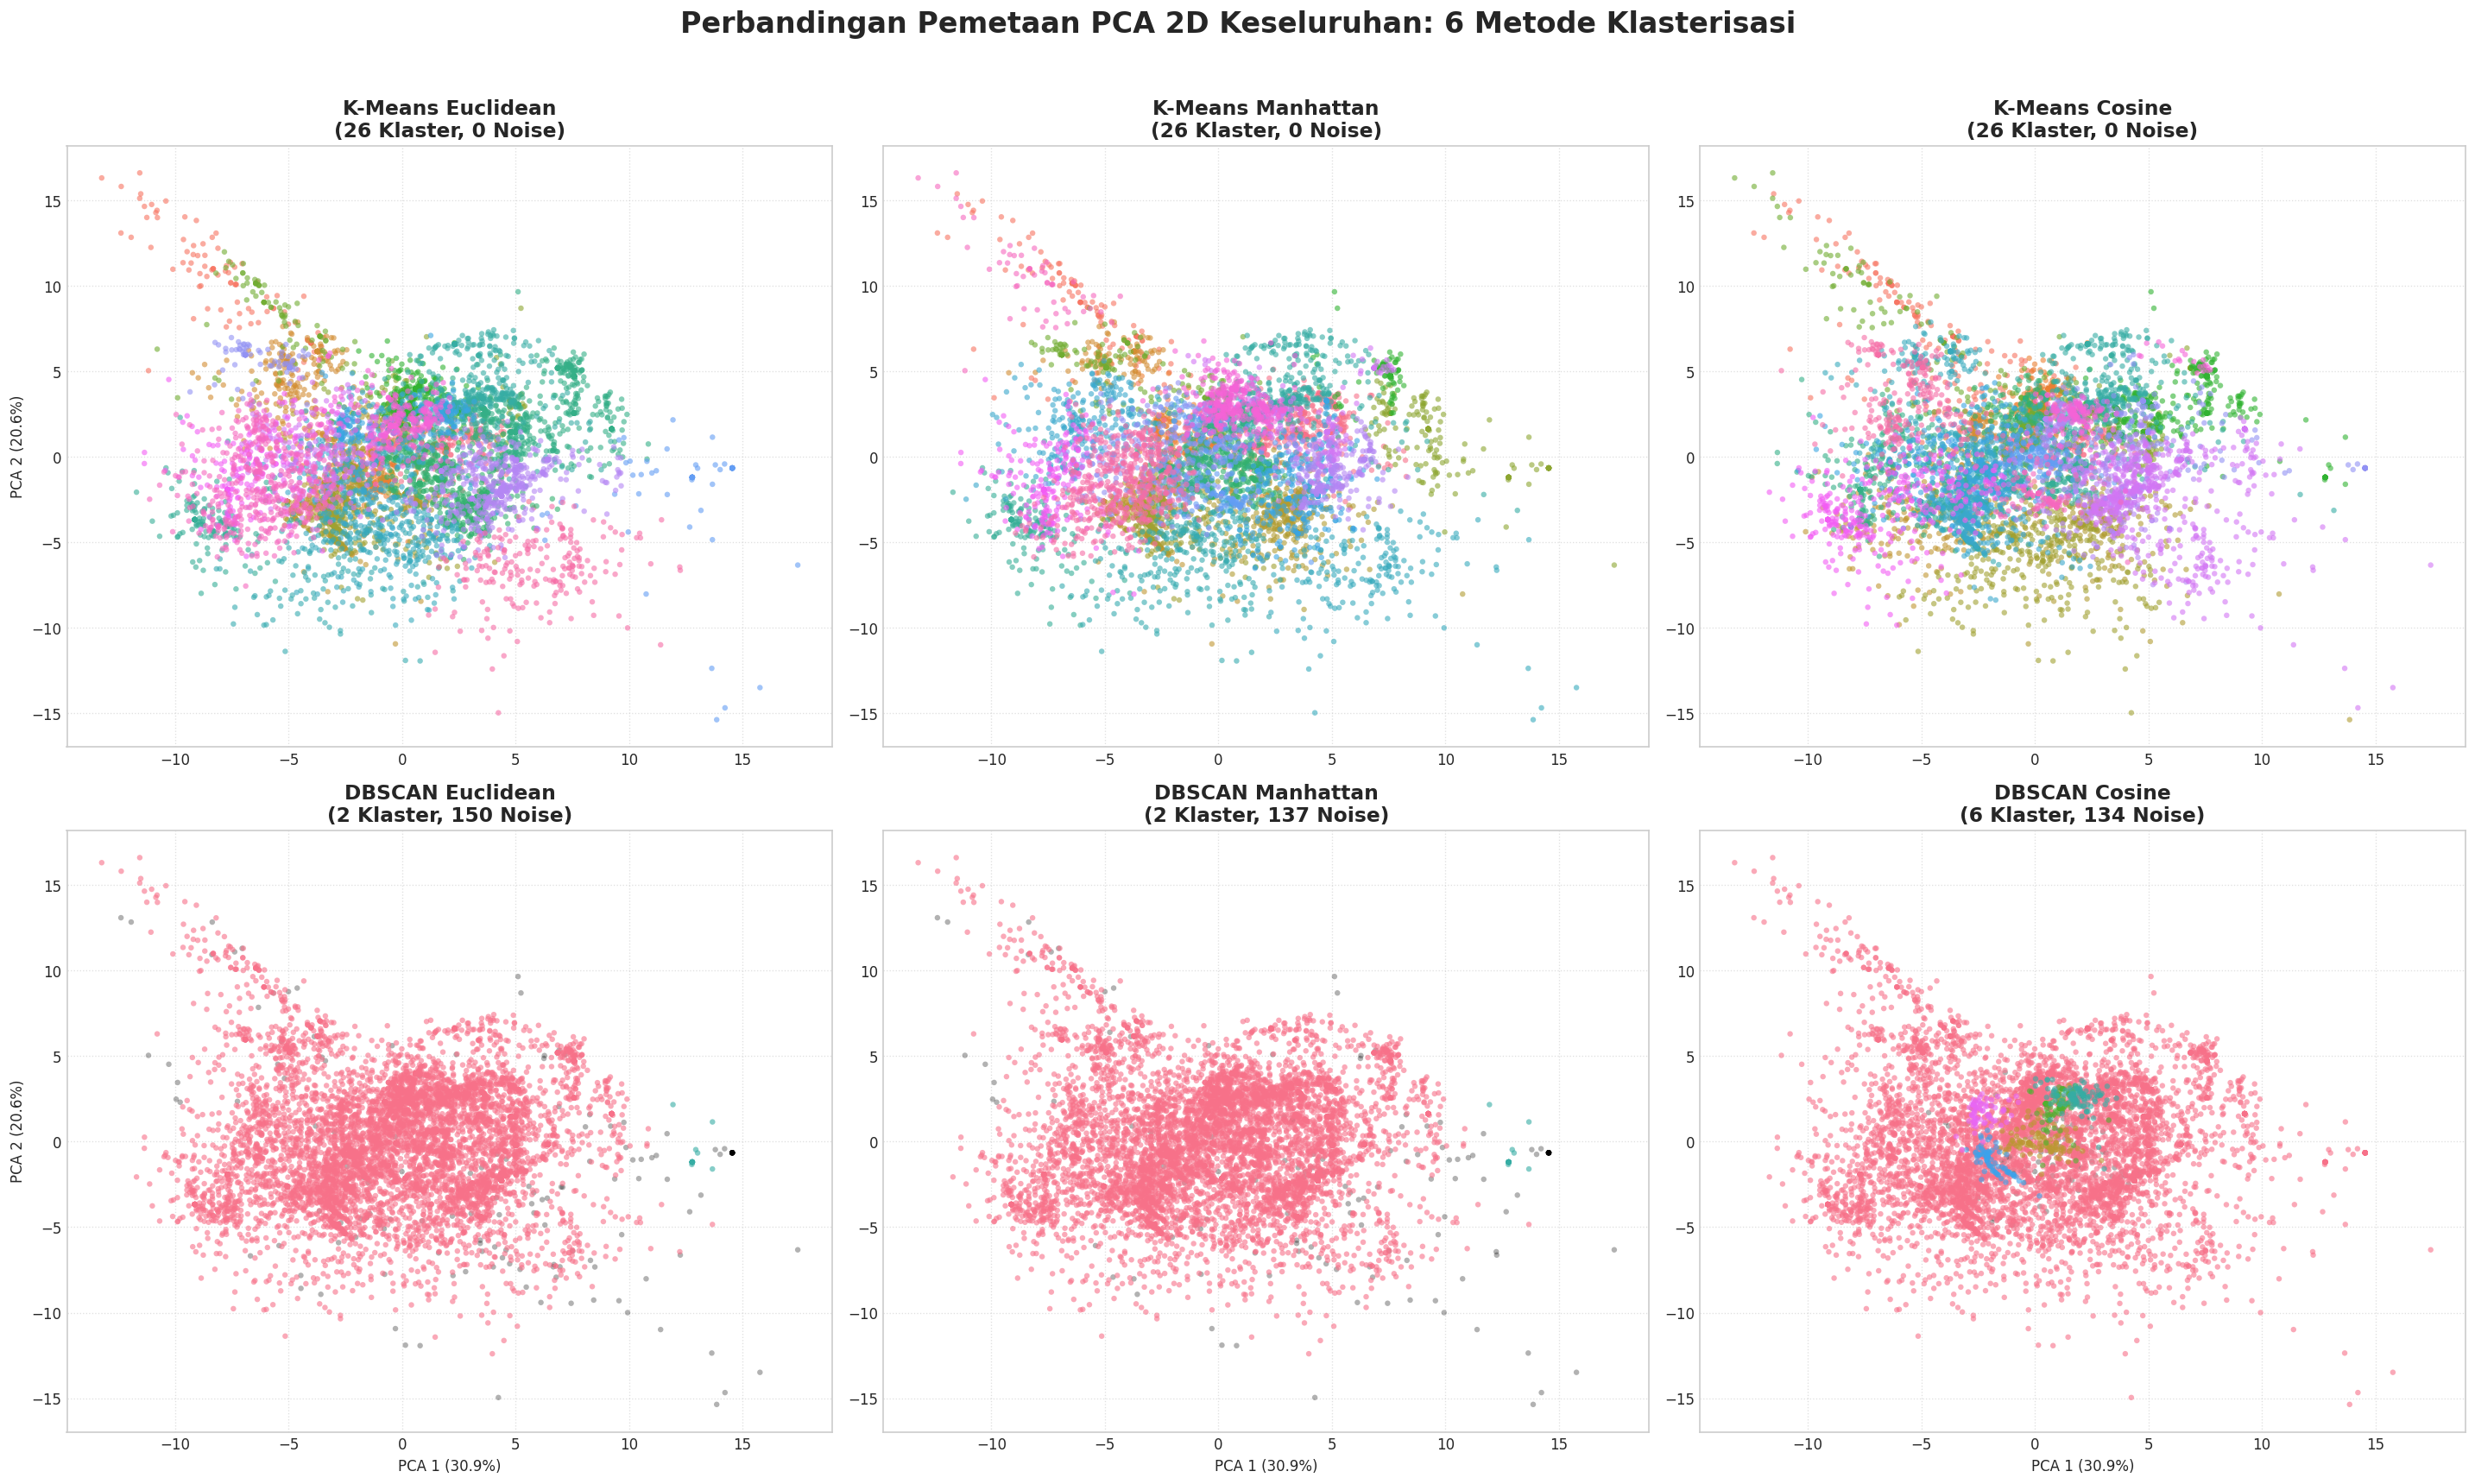

In [36]:
# =======================================================================
# 9.4 VISUALISASI PEMETAAN KLASTER PCA 2D UNTUK 6 METODE SEKALIGUS
# =======================================================================
df_raw_all = data_frames_all['K-Means Euclidean']
cols_to_drop = ['label', 'filename'] + [c for c in df_raw_all.columns if 'Cluster_' in c]
df_features_all = df_raw_all.drop(columns=cols_to_drop, errors='ignore')

scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(df_features_all.values)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_all = pca.fit_transform(X_scaled_all)

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

model_keys = ['K-Means Euclidean', 'K-Means Manhattan', 'K-Means Cosine',
              'DBSCAN Euclidean', 'DBSCAN Manhattan', 'DBSCAN Cosine']

cluster_cols = {
    'K-Means Euclidean': 'Cluster_Euclidean', 'K-Means Manhattan': 'Cluster_Manhattan',
    'K-Means Cosine': 'Cluster_Cosine', 'DBSCAN Euclidean': 'Cluster_DBSCAN_Euclidean',
    'DBSCAN Manhattan': 'Cluster_DBSCAN_Manhattan', 'DBSCAN Cosine': 'Cluster_DBSCAN_Cosine'
}

for i, model_name in enumerate(model_keys):
    ax = axes[i]
    if model_name in data_frames_all:
        col_name = cluster_cols[model_name]
        labels_vis = data_frames_all[model_name][col_name].values
        n_clus = len(set(labels_vis)) - (1 if -1 in labels_vis else 0)
        n_noise = list(labels_vis).count(-1)
        palettes = sns.color_palette("husl", max(1, n_clus))

        noise_mask = (labels_vis == -1)
        if sum(noise_mask) > 0:
            ax.scatter(X_pca_all[noise_mask, 0], X_pca_all[noise_mask, 1], color='black', alpha=0.3, s=15, edgecolors='none', label='Noise')
        for k_idx in range(n_clus):
            mask = (labels_vis == k_idx)
            ax.scatter(X_pca_all[mask, 0], X_pca_all[mask, 1], color=palettes[k_idx], alpha=0.6, s=15, edgecolors='none')

        ax.set_title(f'{model_name}\n({n_clus} Klaster, {n_noise} Noise)', fontsize=14, fontweight='bold')
        if i >= 3:
            ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        if i % 3 == 0:
            ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Perbandingan Pemetaan PCA 2D Keseluruhan: 6 Metode Klasterisasi', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
pca_all_path = os.path.join(OUTPUT_COMPARISON, "master_cluster_comparison_pca2d.png")
plt.savefig(pca_all_path, dpi=300, bbox_inches='tight')
plt.show()

# 🏆 Kesimpulan Akhir & Analisis Visual: Metode Paling Optimal

Berdasarkan komparasi dari 6 skenario metode klasterisasi di atas (didukung dengan visualisasi metrik dan pemetaan PCA 2D), **K-Means dengan metrik jarak Cosine Similarity (Spherical K-Means)** terbukti secara mutlak sebagai metode yang **Paling Optimal** untuk dataset *Hand Landmarks Bisindo*.

**Alasan Utama Kemenangan K-Means Cosine:**
1. **Memenuhi Target Fungsional (26 Klaster):** Terlihat jelas pada grafik target kelas dan plot PCA 2D, DBSCAN gagal memecah dataset karena *Curse of Dimensionality* di dimensi tinggi (hanya memecah menjadi 2-6 klaster raksasa dan menganggap sisanya sebagai *noise*). Algoritma K-Means mengatasi masalah kerumitan topologi ini karena memungkinkan kita menetapkan parameter $K=26$ secara eksplisit sehingga model dipaksa mempartisi ruang secara merata.
2. **Robust Terhadap Skala (Magnitudo):** Metrik *Cosine Similarity* membaca "sudut orientasi" antar jari dan mengabaikan besaran skalar (seberapa besar tangan atau seberapa dekat ke kamera). Hal ini sangat vital dalam pengenalan pose tangan, di mana sebuah isyarat "A" memiliki sudut bentuk yang konsisten meskipun peraganya berbeda. Terlihat pada pemetaan PCA K-Means Cosine, klaster terpisah dengan pola yang jauh lebih sehat (*spherical* di permukaan L2-Norm).
3. **Kualitas Klasterisasi Terbaik:** Dibuktikan secara matematis, metode K-Means Cosine meraih perolehan **Silhouette Score tertinggi (0.3940)**, menunjukkan tingkat kemurnian dan jarak pisah (*margin*) antarkelompok yang paling baik dibanding 5 metode lainnya.

**Rekomendasi Strategis:**
Eksperimen klasterisasi Unsupervised ini memberikan wawasan penting. Ke depannya, ketika membangun model klasifikasi *Supervised* (seperti *Neural Network* atau *SVM*), tim pengembang **sangat disarankan** untuk melakukan normalisasi orientasi pada fitur MediaPipe (*L2 Normalization*) dan menggunakan arsitektur model berbasis fungsi jarak sudut spasial.